In [ ]:
import pandas as pd
df = pd.read_csv(r"/content/freedom_index.csv")

In [ ]:
df.head(5)

,Unnamed: 0,Country,Region,Year,Overall Score,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,0,Singapore,Asia-Pacific,2024,83.5,94.2,88.3,58.3,90.7,89.2,76.0,86.9,77.3,76.3,95.0,90.0,80.0
1,1,Switzerland,Europe,2024,83.0,94.2,91.3,98.1,70.4,64.6,95.7,89.3,60.7,80.8,86.4,85.0,80.0
2,2,Ireland,Europe,2024,82.6,93.5,83.4,94.3,78.0,82.4,91.7,91.3,62.8,74.5,79.2,90.0,70.0
3,3,Taiwan,Asia-Pacific,2024,80.0,82.2,73.4,94.0,79.2,90.5,90.3,84.9,69.1,80.1,86.4,70.0,60.0
4,4,Luxembourg,Europe,2024,79.2,96.9,84.9,95.8,64.6,40.6,97.6,89.5,57.7,69.1,79.2,95.0,80.0


In [ ]:
countries.head()

,pop_est,continent,name,iso_a3,gdp_md_est,geometry,Score
0,0.99672,0.99672,0.99672,0.99672,0.99672,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000...",58.0
1,0.99672,0.99672,0.99672,0.99672,0.99672,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982...",59.1
2,0.99672,0.99672,0.99672,0.99672,0.99672,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",None
3,0.99672,0.99672,0.99672,0.99672,0.99672,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742...",72.4
4,0.99672,0.99672,0.99672,0.99672,0.99672,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000...",70.1


<ipython-input-63-eb5e8dfc16ce>:4: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

<ipython-input-63-eb5e8dfc16ce>:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



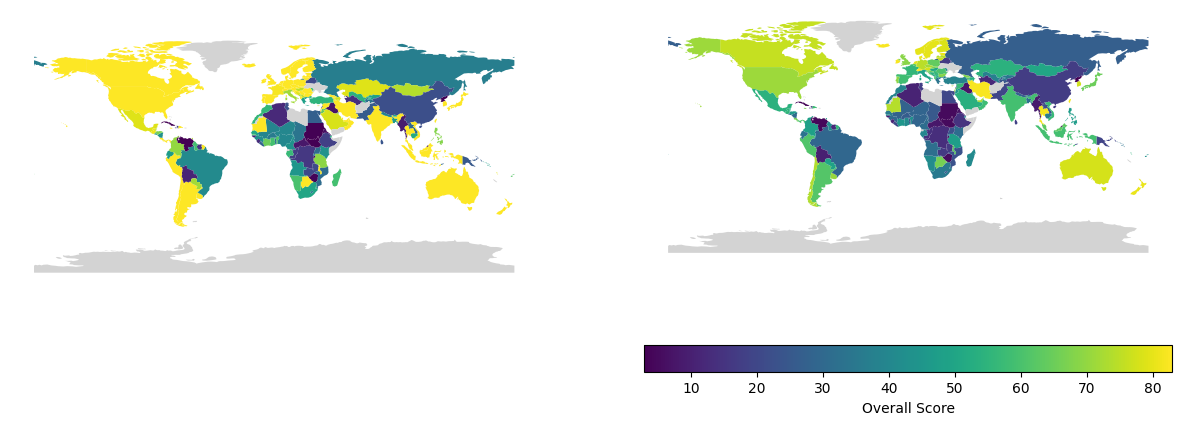

In [ ]:
import geopandas as gpd
import matplotlib as mpl
countries = gpd.read_file(
               gpd.datasets.get_path("naturalearth_lowres"))

from difflib import SequenceMatcher
countries['Score'] = None
df_temp = df[['Country', 'Overall Score']]
df_temp.loc[df_temp["Country"] == "The Philippines", 'Country'] = "Philippines"
df_temp.loc[df_temp["Country"] == "Burma", 'Country'] = "Myanmar"
df_temp.loc[df_temp["Country"] == "Türkiye", 'Country'] = "Turkiye"
df_temp.loc[df_temp["Country"] == "Kyrgyz Republic", 'Country'] = "Kyrgyztan"
df_temp.loc[df_temp["Country"] == "Czech Republic", 'Country'] = "Czechia"
df_temp.loc[df_temp["Country"] == "Republic of Congo", 'Country'] = "Congo"
df_temp.loc[df_temp["Country"] == "Democratic Republic of Congo", 'Country'] = "Dem. Rep. Congo"
df_temp.loc[df_temp["Country"] == "The Bahamas ", 'Country'] = "Bahamas"
df_temp.loc[df_temp["Country"] == "Equatorial Guinea", 'Country'] = "Republic of Equatorial Guinea"
df_temp.loc[df_temp["Country"] == "The Gambia", 'Country'] = "Gambia"

for i, country in enumerate(countries['name']):
    for j, result in enumerate(df_temp['Country']):
        if ((country[0].lower() == result[0].lower()) and (SequenceMatcher(None, country, result).ratio() >= 0.7)):
            countries['Score'][i] = df["Overall Score"][j]
            break

#print(countries.sort_values('name')[['name', 'Score']])

norm = mpl.colors.Normalize(vmin = countries['Score'].min(),
                            vmax = countries['Score'].max())
cmap = 'viridis'
cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
countries.plot(column='Score',
                    missing_kwds={'color': 'lightgrey'},
                    cmap='viridis',
                    norm = norm,
                    ax = ax1).set_axis_off()
countries.plot(column='Score',
                    missing_kwds={'color': 'lightgrey'},
                    cmap='viridis',
                    ax = ax2).set_axis_off()
fig.colorbar(cbar, ax=ax2, orientation ='horizontal',
               label ='Overall Score')

In [ ]:
df_pca = df.select_dtypes(include=[int, float])
df_pca = df_pca.drop(columns = ['Overall Score', 'Year', 'Unnamed: 0'])
df_pca.head()

,Property Rights,Government Integrity,Judicial Effectiveness,Tax Burden,Government Spending,Fiscal Health,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom
0,94.2,88.3,58.3,90.7,89.2,76.0,86.9,77.3,76.3,95.0,90.0,80.0
1,94.2,91.3,98.1,70.4,64.6,95.7,89.3,60.7,80.8,86.4,85.0,80.0
2,93.5,83.4,94.3,78.0,82.4,91.7,91.3,62.8,74.5,79.2,90.0,70.0
3,82.2,73.4,94.0,79.2,90.5,90.3,84.9,69.1,80.1,86.4,70.0,60.0
4,96.9,84.9,95.8,64.6,40.6,97.6,89.5,57.7,69.1,79.2,95.0,80.0


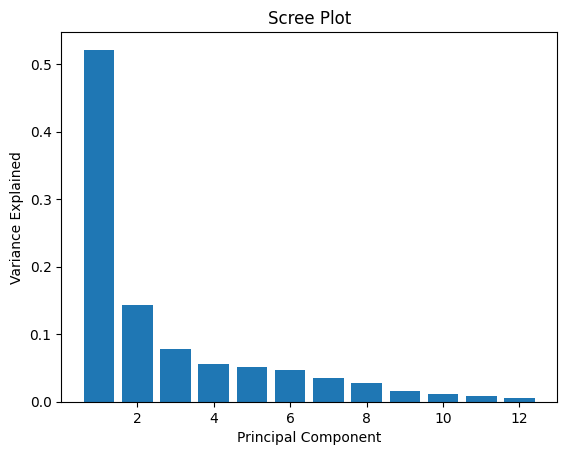

In [ ]:
#Create Scree Plot to find the num of significant Principle Component
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components = 12)
X = pca.fit_transform(X_scaled)

PC_values = np.arange(pca.n_components_) + 1
plt.bar(PC_values, pca.explained_variance_ratio_)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()
#print(pca.explained_variance_ratio_)

In [ ]:
# Data Cleaning
# Not needed
df_numerical = df.select_dtypes(include=[int, float])
df_numerical = df_numerical.drop(columns = 'Overall Score')

# All Gaussian Clustering

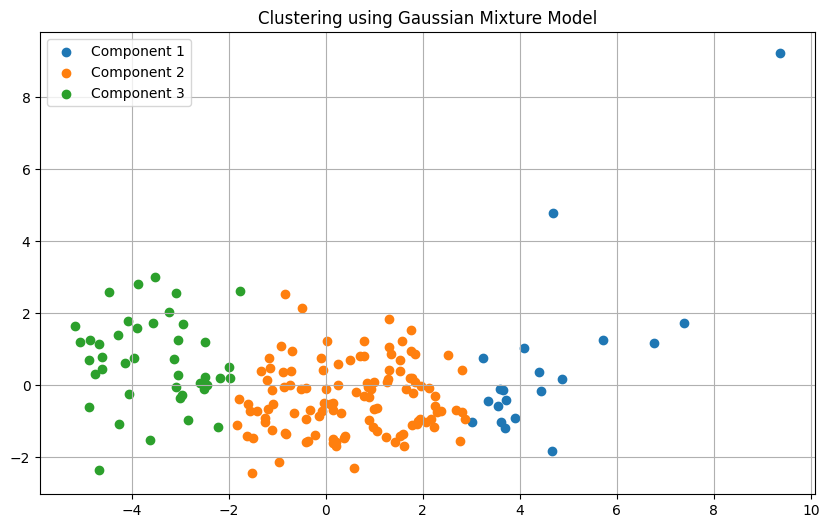

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 1 2 2 1 2 2 1 2 1 1
 2 2 1 1 2 1 2 1 2 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Memisahkan nama negara
country_names = df['Country']

X_all = df[['Overall Score', 'Property Rights', 'Government Integrity', 'Judicial Effectiveness',
            'Tax Burden', 'Government Spending', 'Fiscal Health', 'Business Freedom',
            'Labor Freedom', 'Monetary Freedom', 'Trade Freedom', 'Investment Freedom', 'Financial Freedom']]

#Scaller
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Reduksi dimensi menggunakan PCA agar dapat divisualisasikan
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Membuat model GMM dengan 3 kelompok
gmm = GaussianMixture(n_components=3, covariance_type='spherical', max_iter=100, init_params='k-means++', random_state=0)
gmm.fit(X_scaled)

# Memprediksi label dari data
labels = gmm.predict(X_scaled)

# Visualisasi hasil clustering
# plt.figure(figsize=(40, 25))
plt.figure(figsize=(10, 6))

for label in np.unique(labels):
    plt.scatter(X_pca[labels == label, 0], X_pca[labels == label, 1], label=f'Component {label+1}')

plt.title('Clustering using Gaussian Mixture Model')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')

# Menambahkan label nama negara pada setiap titik
# for i, txt in enumerate(country_names):
#     plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]))

plt.grid(True)
plt.legend()
plt.show()
print(labels)
# for label in np.unique(labels):
#     print(f'\nCluster {label + 1}:')
#     cluster_countries = country_names[labels == label]
#     for country in cluster_countries:
#         print(country)

results = pd.DataFrame({'Country': country_names, 'Cluster': labels})
# Mengurutkan berdasarkan nama negara
results_sorted = results.sort_values(by='Country')

# Mencetak hasil
# for index, row in results_sorted.iterrows():
    # print(f'{row["Country"]}: Cluster {row["Cluster"]}')
    # print(f'{row["Cluster"]}')

For n_clusters = 2 The average silhouette_score is : 0.3897447618243586
For n_clusters = 3 The average silhouette_score is : 0.37648934175791543
For n_clusters = 4 The average silhouette_score is : 0.2966481477243708
For n_clusters = 5 The average silhouette_score is : 0.2842406950653744
For n_clusters = 6 The average silhouette_score is : 0.2519302828758695
For n_clusters = 7 The average silhouette_score is : 0.2559984460499319
For n_clusters = 8 The average silhouette_score is : 0.20634307658207804


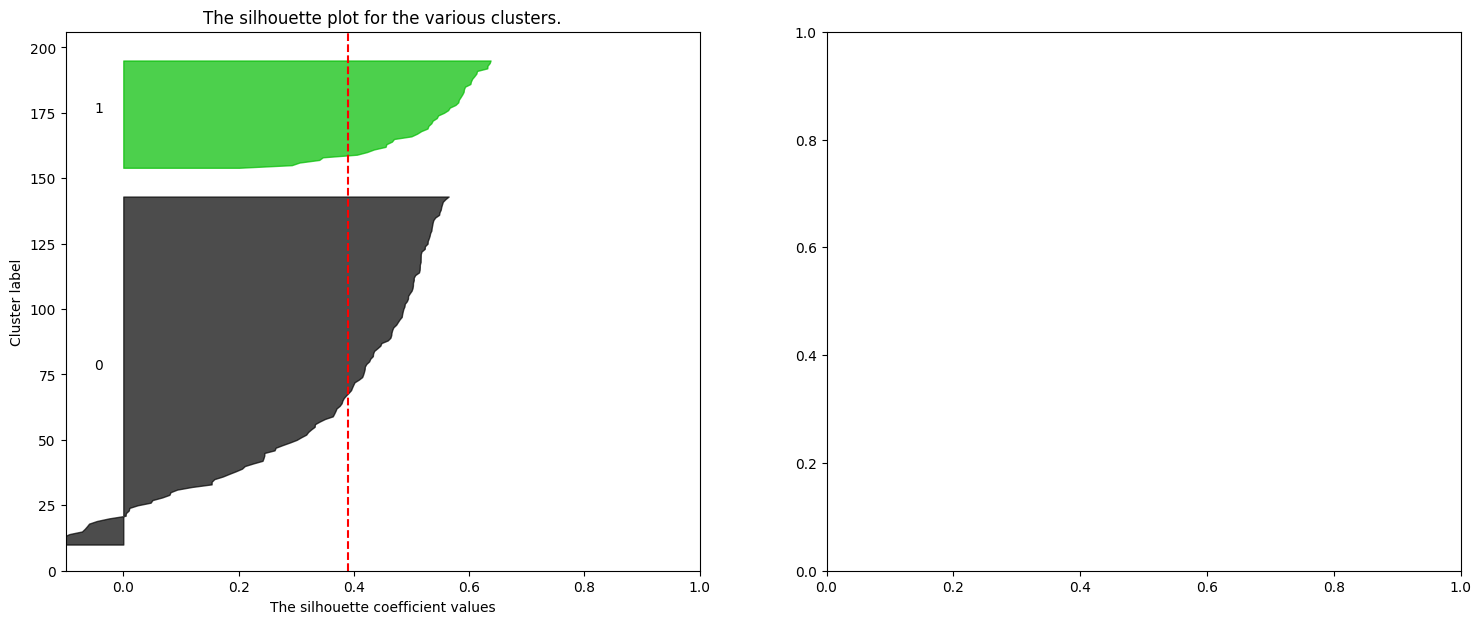

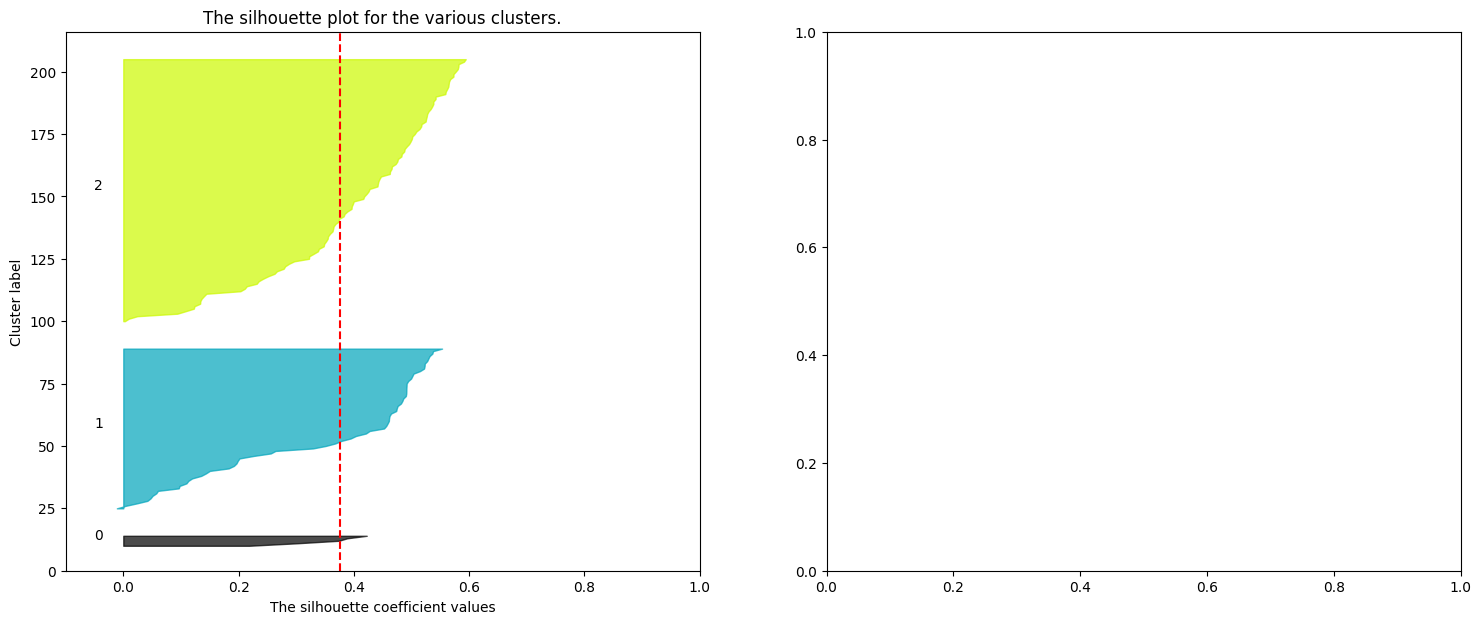

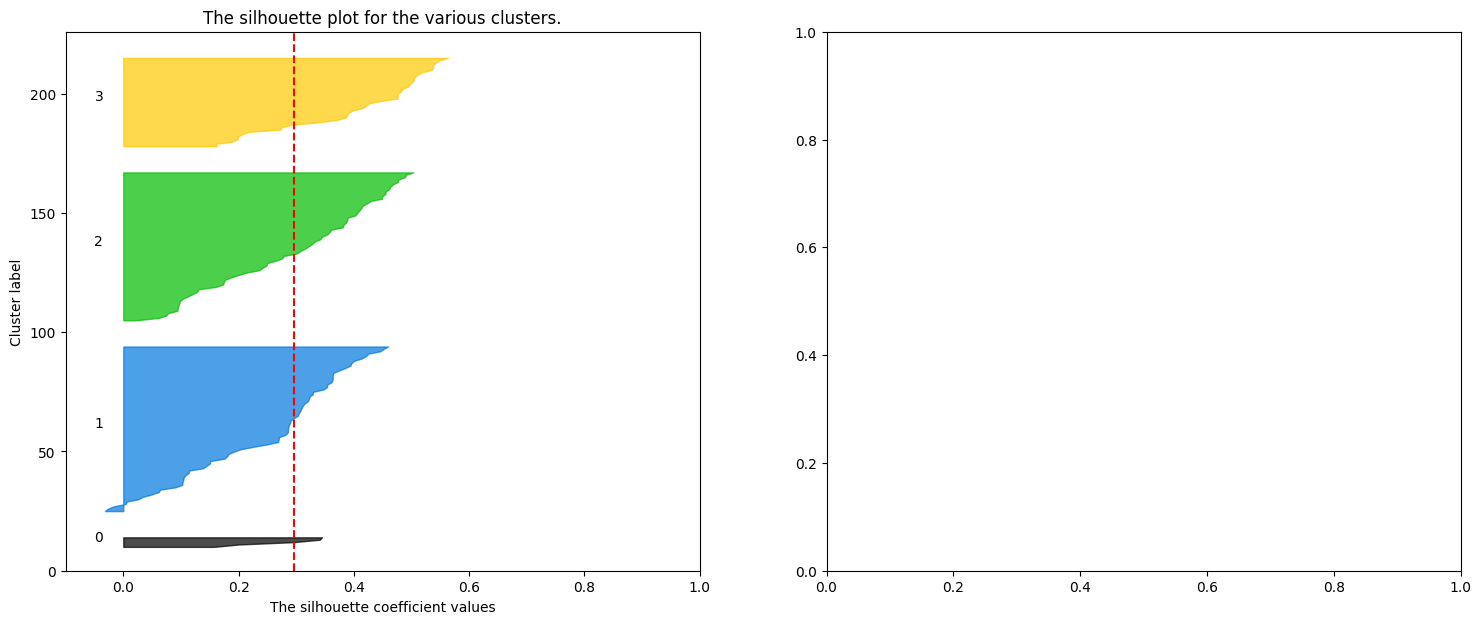

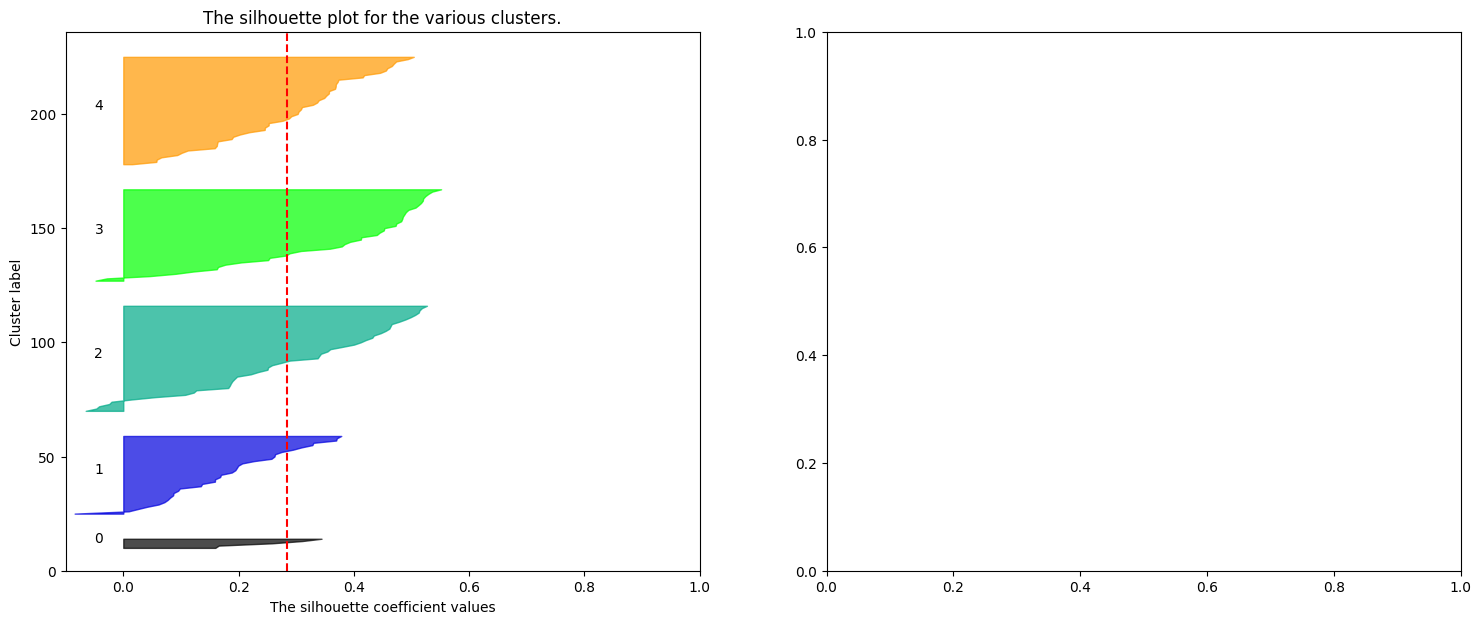

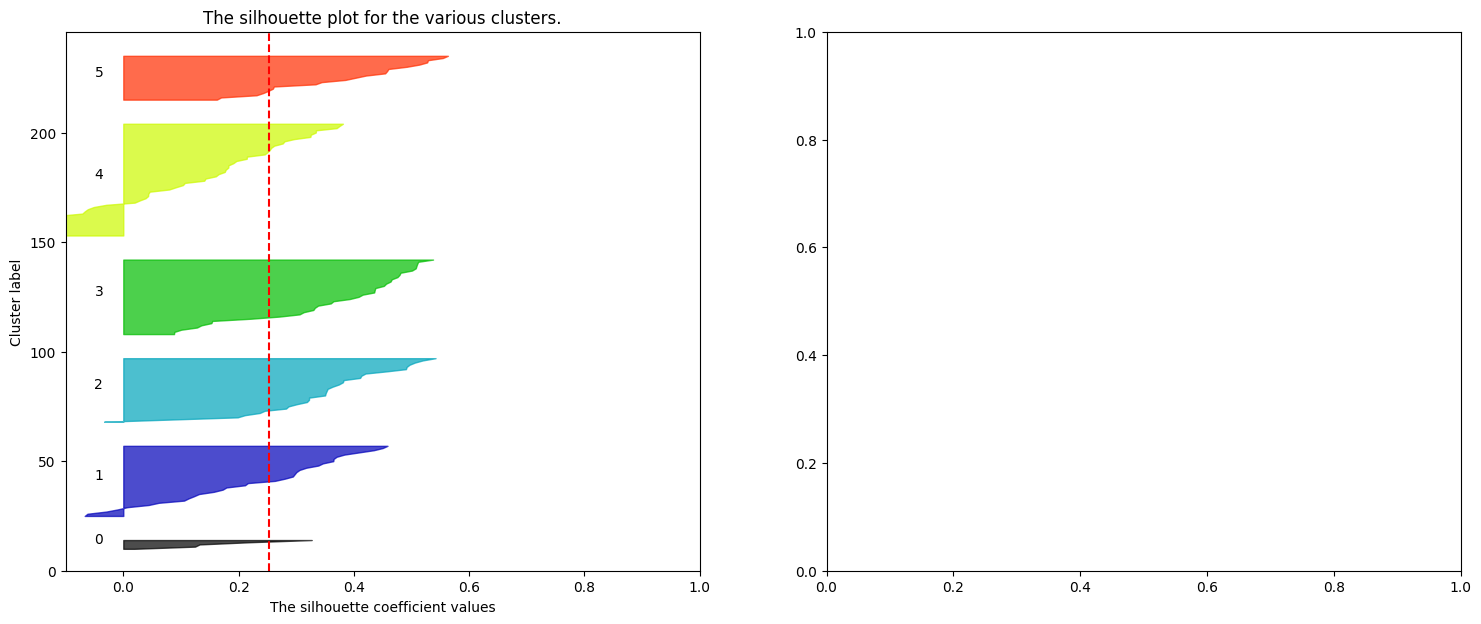

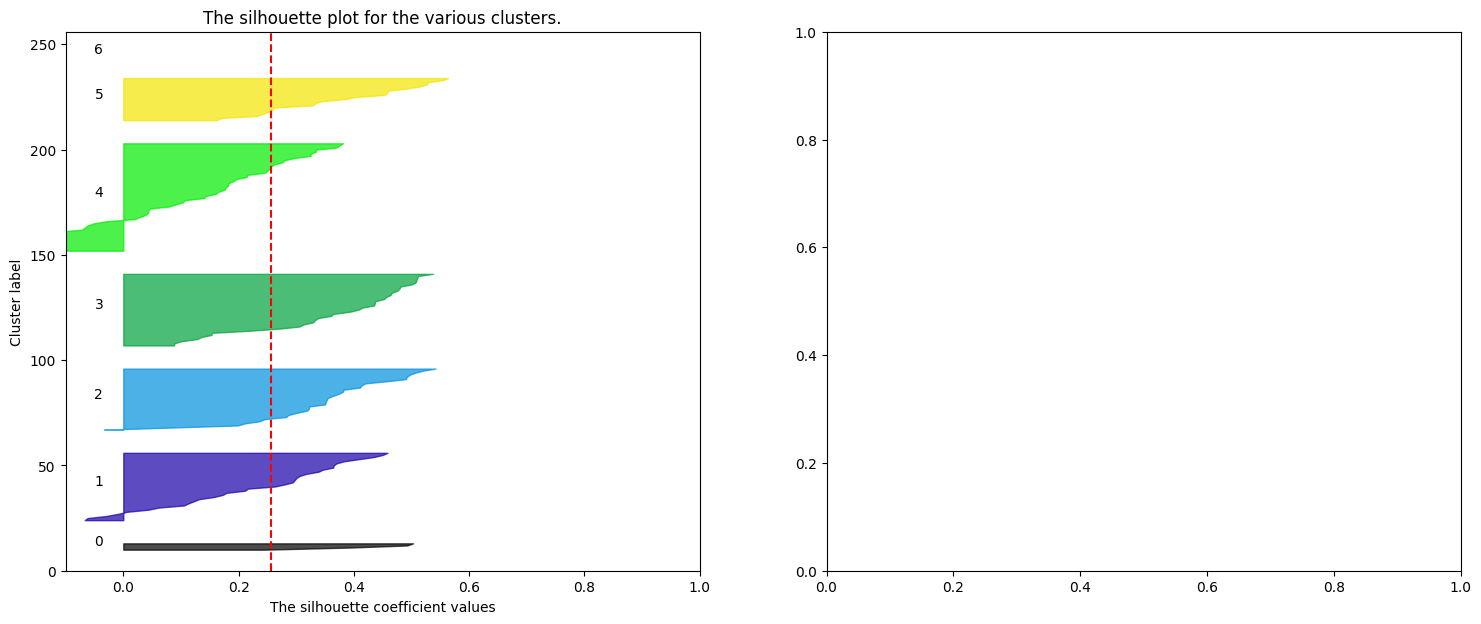

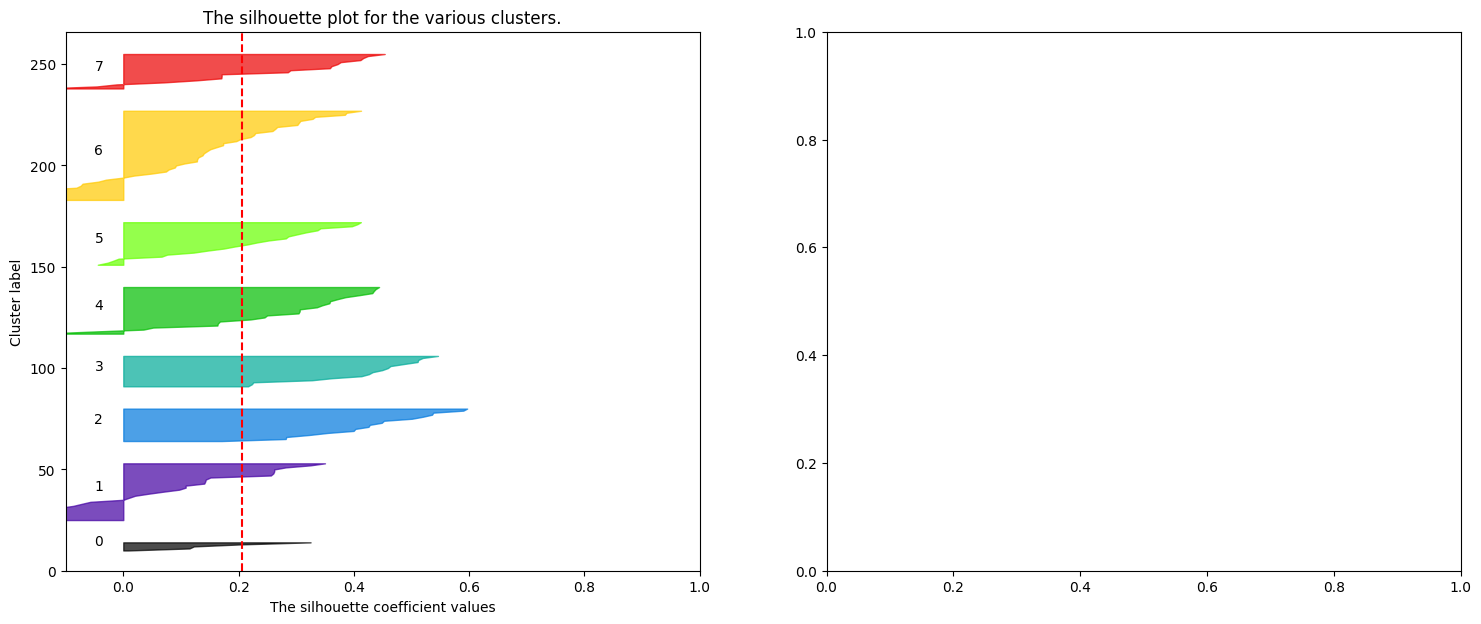

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

for n_clusters in range(2, 9):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = GaussianMixture(n_components=n_clusters, covariance_type='spherical', max_iter=100, init_params='k-means++', random_state=0)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")


plt.show()

[20334.94409807789]
[20334.94409807789, 19653.638366834468]
[20334.94409807789, 19653.638366834468, 19360.73297789174]
[20334.94409807789, 19653.638366834468, 19360.73297789174, 19117.893607346698]
[20334.94409807789, 19653.638366834468, 19360.73297789174, 19117.893607346698, 19000.842907867544]
[20334.94409807789, 19653.638366834468, 19360.73297789174, 19117.893607346698, 19000.842907867544, 18904.605341289323]


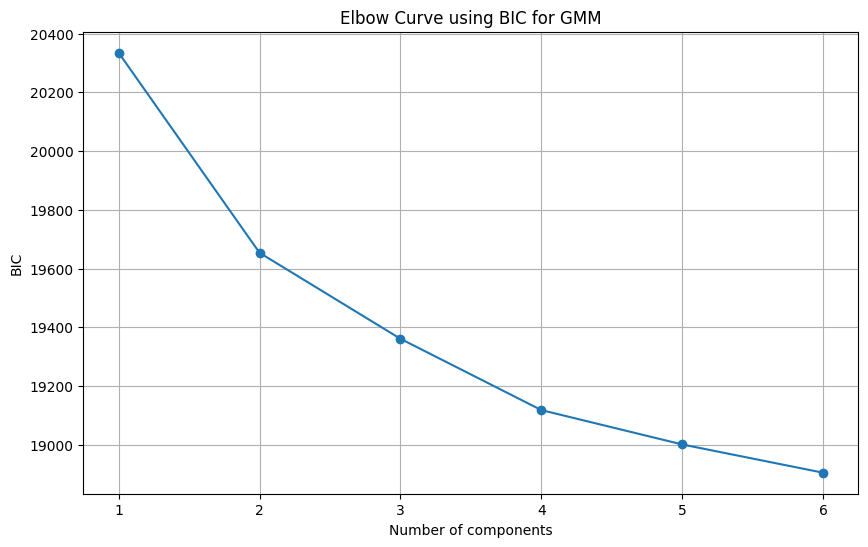

In [ ]:
# Menentukan rentang jumlah cluster yang ingin diuji
n_components_range = range(1, 7)

# Inisialisasi list untuk menyimpan BIC
bic = []

# Fit GMM untuk berbagai jumlah cluster dan hitung BIC
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='spherical', max_iter=100, init_params='k-means++', random_state=0)
    gmm.fit(X_all)
    bic.append(gmm.bic(X_all))
    print(bic)

# Plot BIC terhadap jumlah cluster
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic, marker='o')
plt.title('Elbow Curve using BIC for GMM')
plt.xlabel('Number of components')
plt.ylabel('BIC')
plt.xticks(n_components_range)
plt.grid(True)
plt.show()

<ipython-input-67-017322072567>:2: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

<ipython-input-67-017322072567>:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



                              Country  Cluster
0                           Singapore        2
1                         Switzerland        2
2                             Ireland        2
3                              Taiwan        2
4                          Luxembourg        2
5                             Denmark        2
6                             Estonia        2
7                         New Zealand        2
8                              Norway        2
9                              Sweden        2
10                        Netherlands        2
11                            Finland        2
12                          Australia        2
13                        South Korea        2
14                          Lithuania        2
15                             Canada        2
16                             Cyprus        2
17                            Germany        2
18                             Latvia        2
19                          Mauritius        2
20           

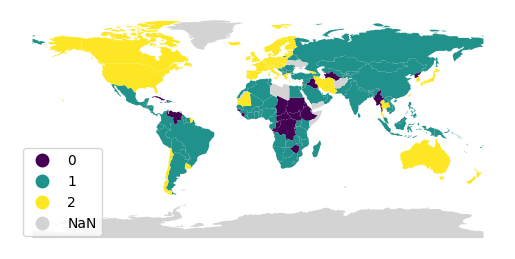

In [ ]:
import geopandas as gpd
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
countries.head()
from difflib import SequenceMatcher
countries['labels'] = None
# Membuat DataFrame untuk negara dan label clusternya
df_sorted = pd.DataFrame({'Country': country_names, 'Cluster': labels})
df_sorted.loc[df_sorted["Country"] == "The Philippines", 'Country'] = "Philippines"
df_sorted.loc[df_sorted["Country"] == "Burma", 'Country'] = "Myanmar"
df_sorted.loc[df_sorted["Country"] == "Türkiye", 'Country'] = "Turkiye"
df_sorted.loc[df_sorted["Country"] == "Kyrgyz Republic", 'Country'] = "Kyrgyztan"
df_sorted.loc[df_sorted["Country"] == "Czech Republic", 'Country'] = "Czechia"
df_sorted.loc[df_sorted["Country"] == "Republic of Congo", 'Country'] = "Congo"
df_sorted.loc[df_sorted["Country"] == "Democratic Republic of Congo", 'Country'] = "Dem. Rep. Congo"
df_sorted.loc[df_sorted["Country"] == "The Bahamas ", 'Country'] = "Bahamas"
df_sorted.loc[df_sorted["Country"] == "Equatorial Guinea", 'Country'] = "Republic of Equatorial Guinea"
df_sorted.loc[df_sorted["Country"] == "The Gambia", 'Country'] = "Gambia"


print(df_sorted)
for i, country in enumerate(countries['name']):
    for j, result in enumerate(df_sorted['Country']):
        if ((country[0].lower() == result[0].lower()) and (SequenceMatcher(None, country, result).ratio() >= 0.7)):
            countries['labels'][i] = df_sorted["Cluster"][j]
            break

print(countries.sort_values('name')[['name', 'labels']])
#Legend still needs adjustments
pd.set_option('display.max_rows', None)
countries["name"]
# countries.plot(column='labels', missing_kwds={'color': 'lightgrey'}, cmap='viridis', legend = True).set_axis_off()
ax = countries.plot(column='labels',
                    missing_kwds={'color': 'lightgrey'},
                    cmap='viridis',
                    legend=True)

# Remove the axis
ax.set_axis_off()

# Customize the legend
leg = ax.get_legend()
leg.set_bbox_to_anchor((0.05, 0.25, 0.15, 0.2)) # Adjust the position and size of the legend box
leg._legend_box.align = "left" # Align the legend entries to the left

plt.show()


In [ ]:
countries['labels']

# Hierarchical Clustering Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

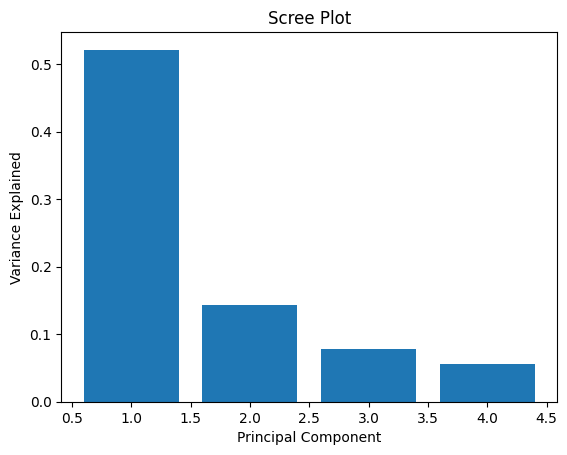

[0.5215461  0.14364731 0.07768801 0.05532461]
0.7982060338214196


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_pca = df.select_dtypes(include=[int, float])
df_pca = df_pca.drop(columns = ['Overall Score', 'Year', 'Unnamed: 0'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA(n_components = 4)
X = pca.fit_transform(X_scaled)
#df_new.columns = ['P1', 'P2', 'P3']

PC_values = np.arange(pca.n_components_) + 1
#plt.figure(figsize = (2,3))
plt.bar(PC_values, pca.explained_variance_ratio_)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()
print(pca.explained_variance_ratio_)
pca_percent = 0
for i in pca.explained_variance_ratio_:
  pca_percent += i
print(pca_percent)

Silh. Score for k = 2: 0.33048801602266864
Silh. Score for k = 3: 0.24062212013673537
Silh. Score for k = 4: 0.26677854951389485
Silh. Score for k = 5: 0.22531605506199623
Silh. Score for k = 6: 0.2359024811746475
Silh. Score for k = 7: 0.23571495047521615
Silh. Score for k = 8: 0.23933184657606466
Silh. Score for k = 9: 0.22655165473685146


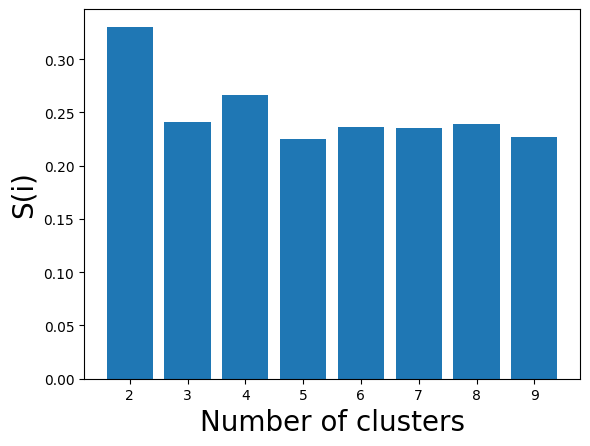

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestCentroid

k = range(2,10)

ac_list = [AgglomerativeClustering(n_clusters = i) for i in k]

# Appending the silhouette scores
silhouette_scores = {}
silhouette_scores.fromkeys(k)

for i,j in enumerate(k):
    silhouette_scores[j] = silhouette_score(X,
                        ac_list[i].fit_predict(X))

for i,ss in enumerate(silhouette_scores.values()):
  print(f'Silh. Score for k = {i+2}: {ss}')

# Plotting
y = list(silhouette_scores.values())
plt.bar(k, y)
plt.xlabel('Number of clusters', fontsize = 20)
plt.ylabel('S(i)', fontsize = 20)
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


For n_clusters = 2 The average silhouette_score is : 0.33048801602266864
For n_clusters = 3 The average silhouette_score is : 0.24062212013673537
For n_clusters = 4 The average silhouette_score is : 0.26677854951389485


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


For n_clusters = 5 The average silhouette_score is : 0.22531605506199623
For n_clusters = 6 The average silhouette_score is : 0.2359024811746475
For n_clusters = 7 The average silhouette_score is : 0.23571495047521615


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


For n_clusters = 8 The average silhouette_score is : 0.23933184657606466
For n_clusters = 9 The average silhouette_score is : 0.22655165473685146


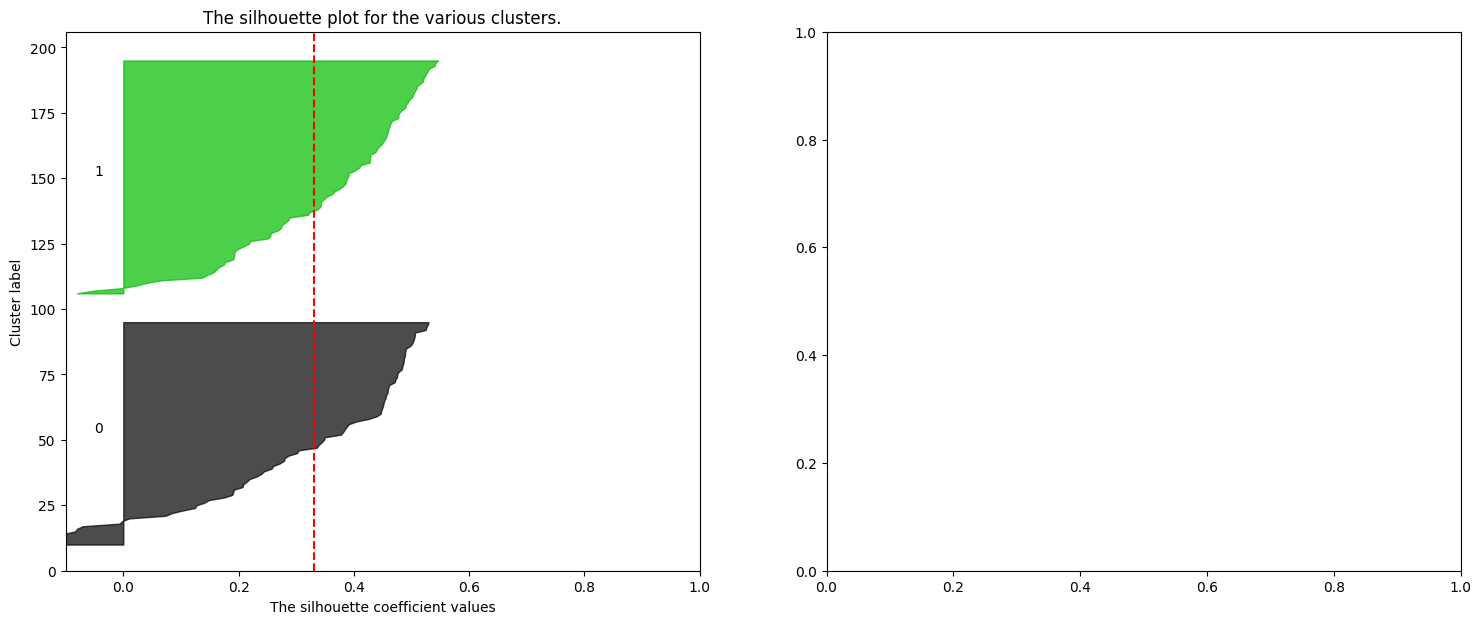

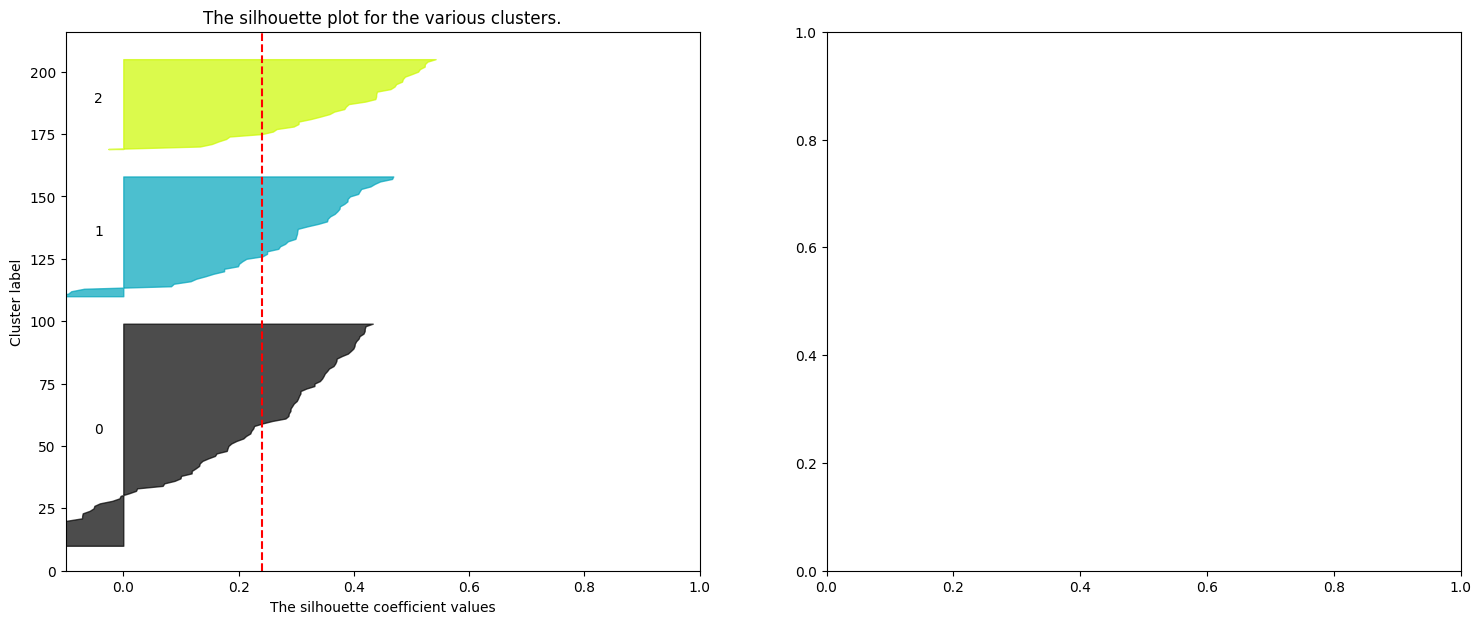

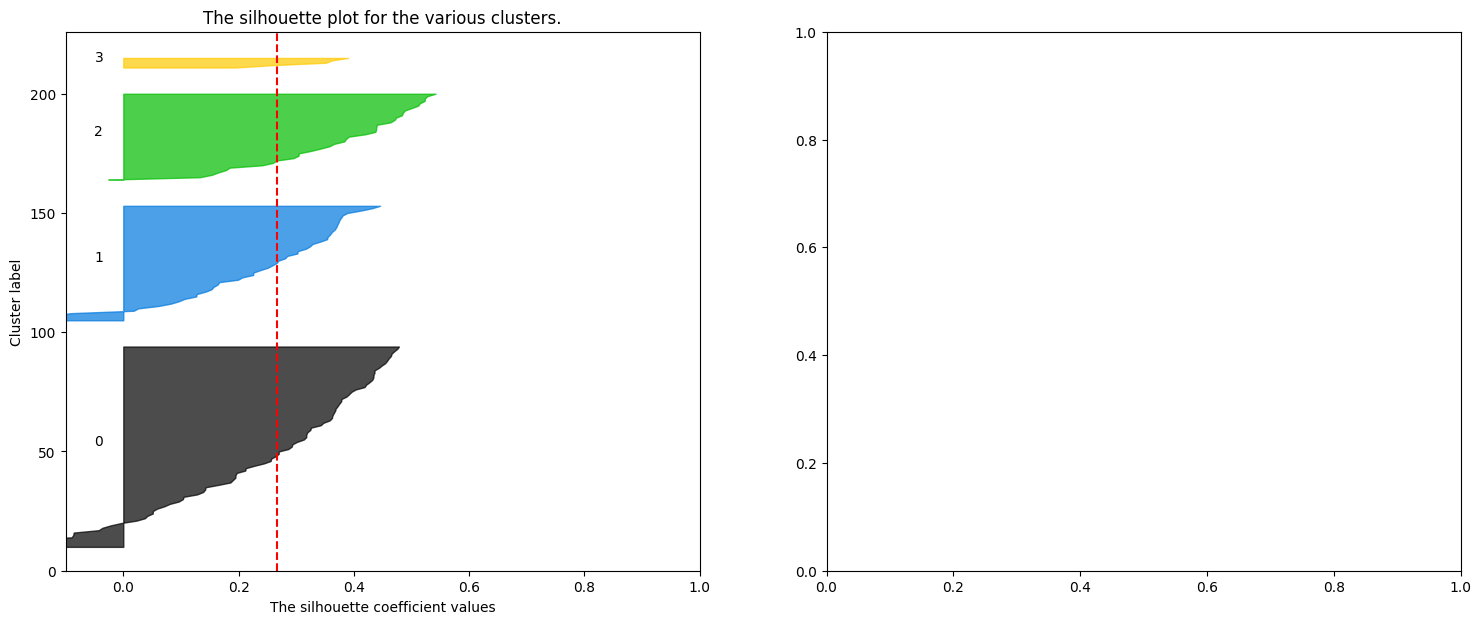

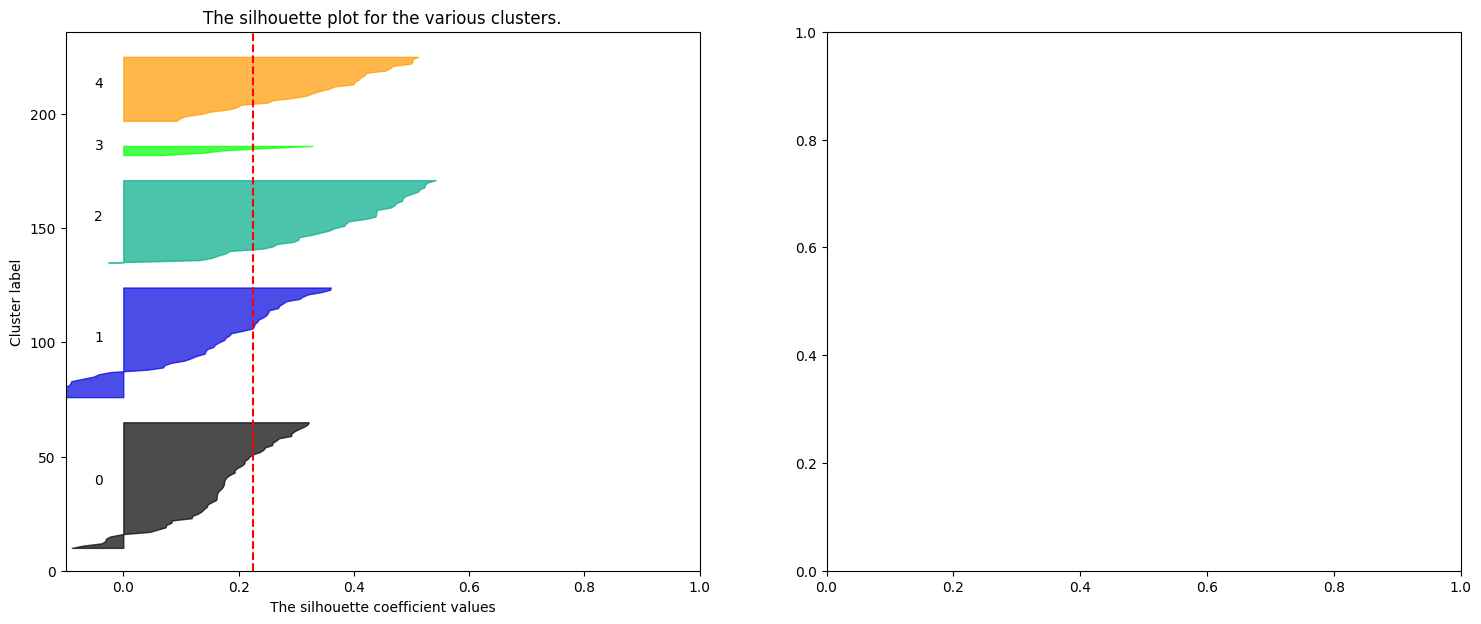

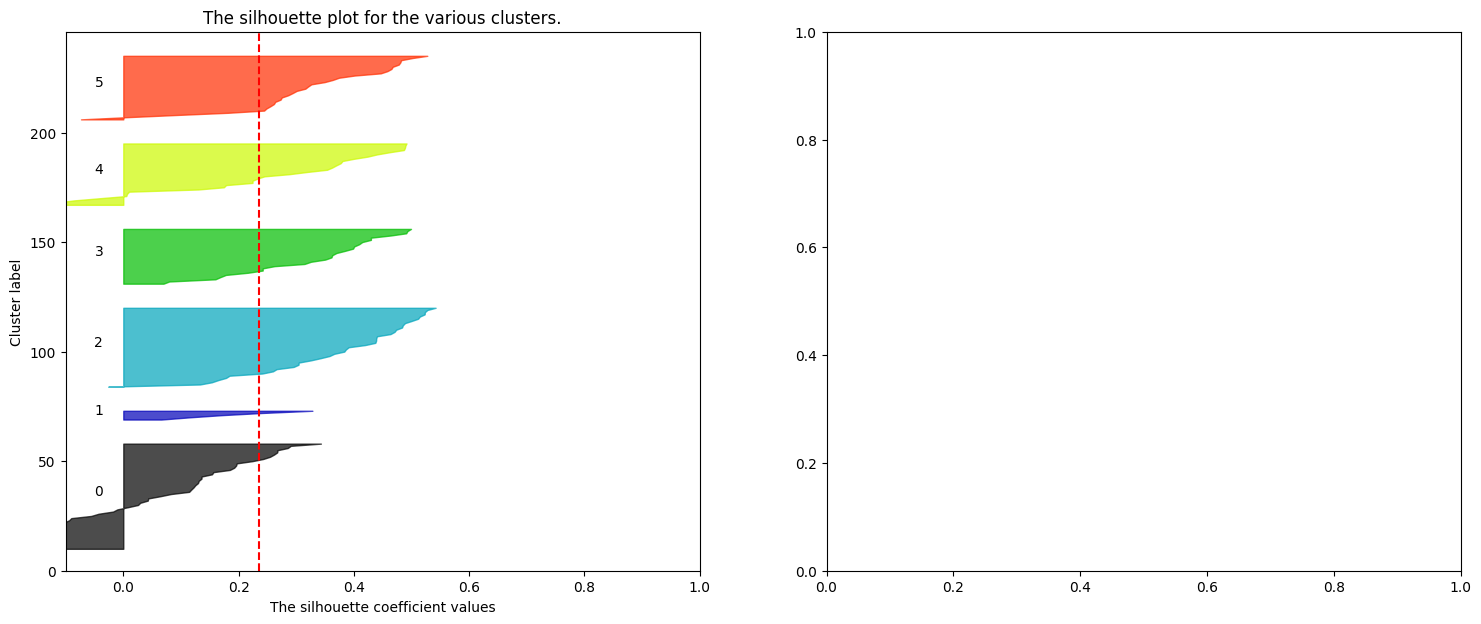

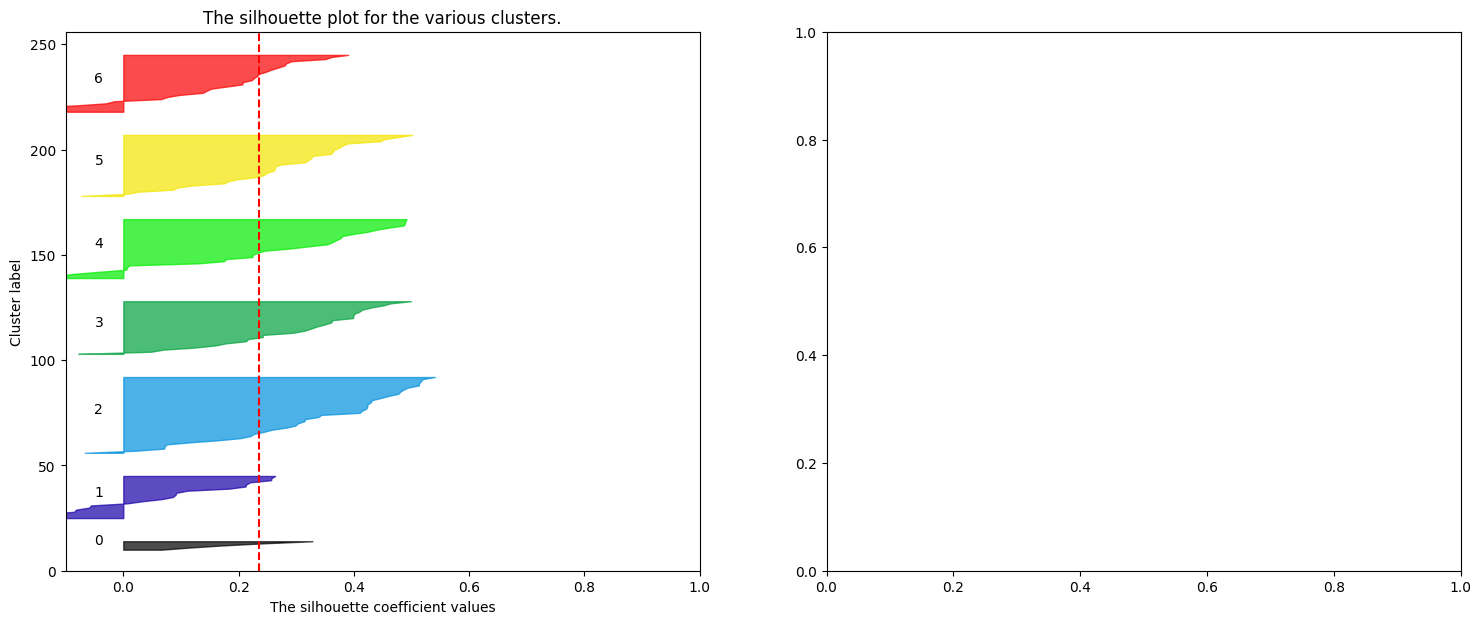

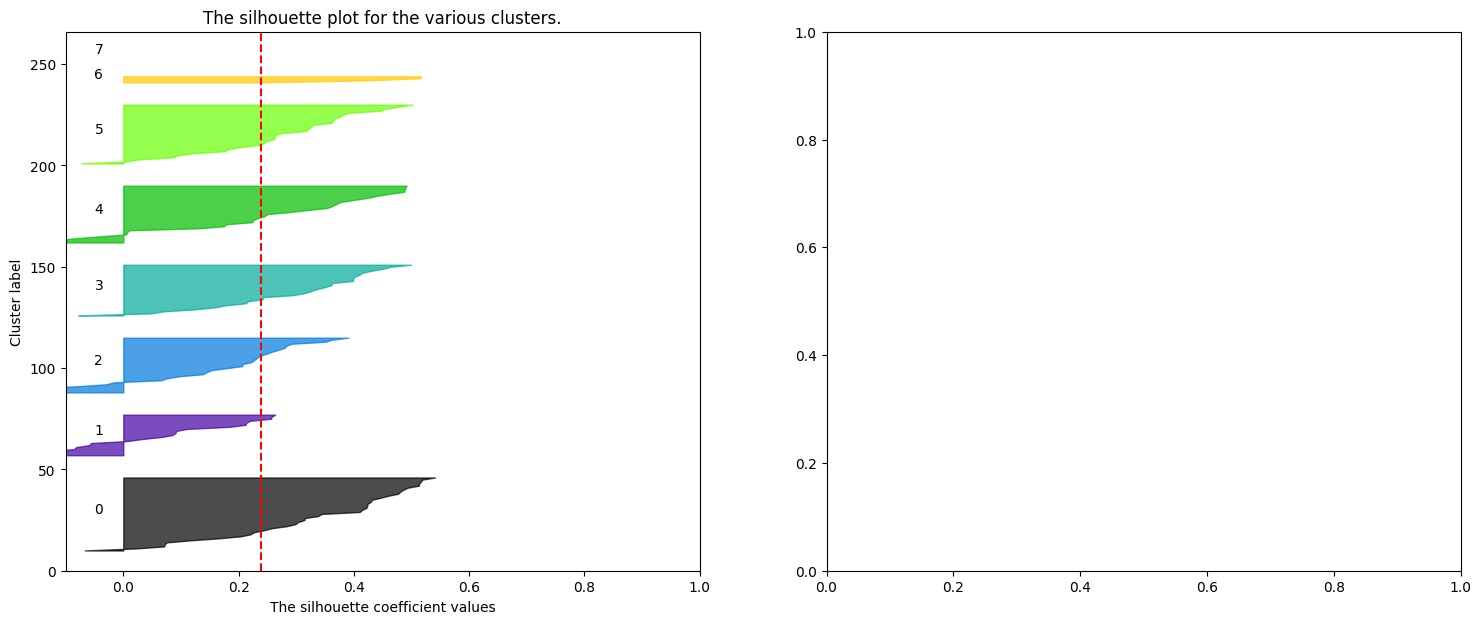

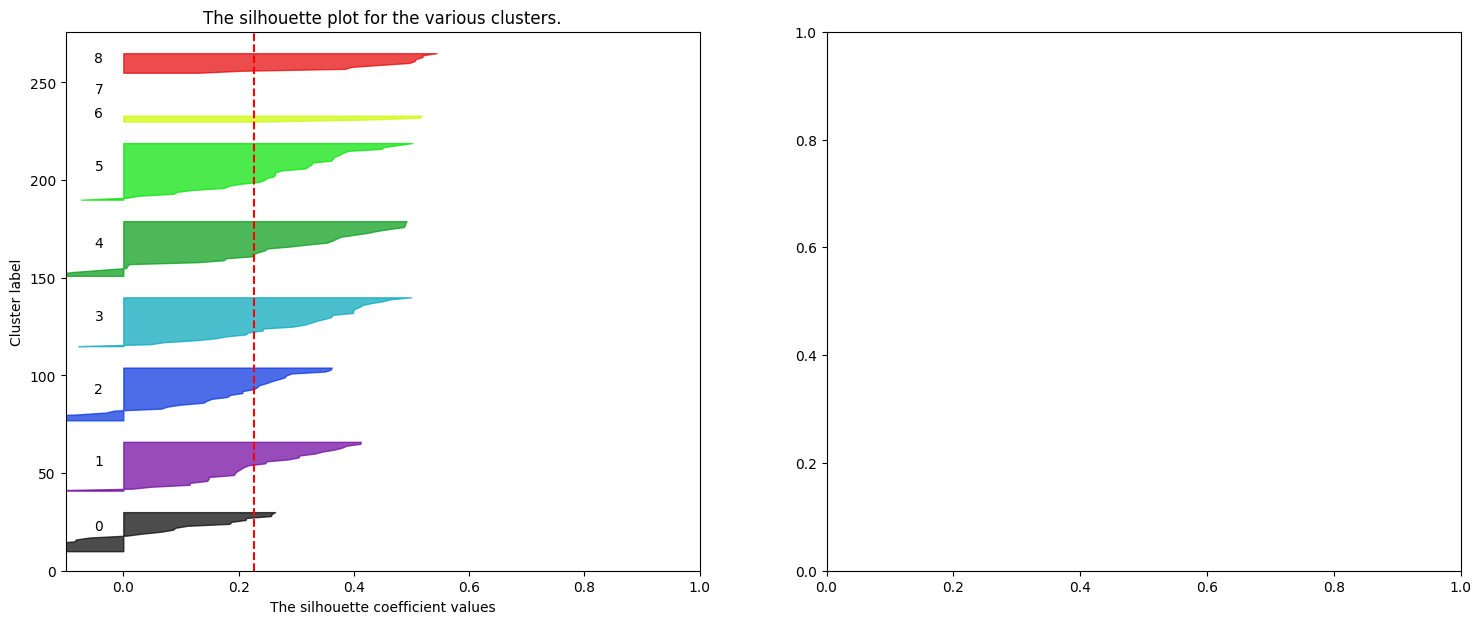

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_score1 = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_score1,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_score1, color="red", linestyle="--")


plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be

Text(0.5, 1.0, 'Elbow curve')

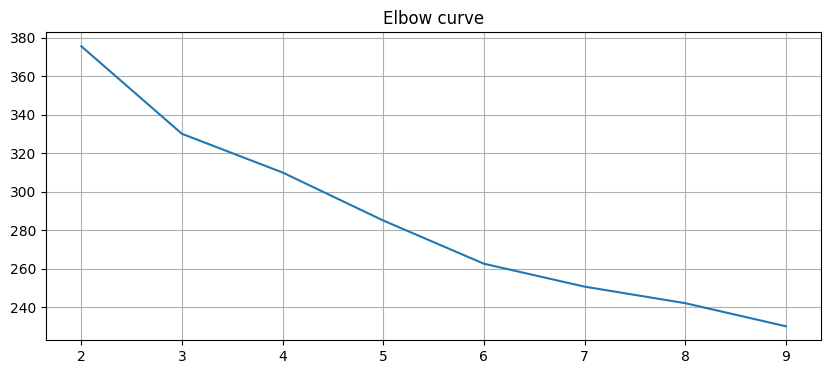

In [ ]:
from sklearn.neighbors import NearestCentroid

distorsions = []
def cluster_inertia(k, data):
    clusterer = AgglomerativeClustering(n_clusters=k, affinity='euclidean', linkage='ward')
    y_predict = clusterer.fit_predict(data)
    clf = NearestCentroid()
    clf.fit(data, y_predict)

    inertia = 0
    for idx in range(k):
      X_idx = data[y_predict == idx]
      for j in range(X_idx.shape[0]):
        inertia += np.sqrt(np.dot(X_idx[j] - clf.centroids_[idx], X_idx[j] - clf.centroids_[idx]))
    return inertia

for k in range(2, 10):
    distorsions.append(cluster_inertia(k, X))

plt.figure(figsize = (10,4))
plt.plot(range(2, 10), distorsions)
plt.grid(True)
plt.title('Elbow curve')

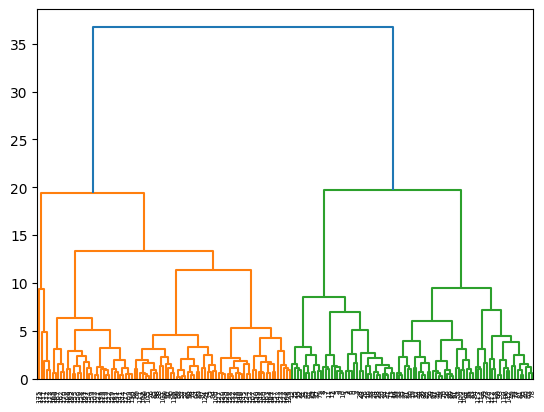

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0 0
 1 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 0
 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
linkage_data = linkage(X, method='ward', metric='euclidean')
dendrogram(linkage_data)
plt.show()

hierarchical_cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
labels = hierarchical_cluster.fit_predict(X)
print(labels)

In [ ]:
df_country = df['Country']
df_sorted = {}
df_sorted = pd.DataFrame(df_sorted)
df_sorted.insert(0, "Country", df_country)
df_sorted.insert(1, "Cluster", labels)
df_sorted.sort_values('Country')

,Country,Cluster
47,Albania,0
163,Algeria,1
117,Angola,1
143,Argentina,1
46,Armenia,0
...,...,...
64,Vanuatu,1
173,Venezuela,1
58,Vietnam,1
152,Zambia,1


<ipython-input-15-7c30c5fb8291>:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
<ipython-input-15-7c30c5fb8291>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries['labels'][i] = df_sorted["Cluster"][j]


            name labels
103  Afghanistan   None
125      Albania      0
82       Algeria      1
74        Angola      1
159   Antarctica   None
..           ...    ...
2      W. Sahara   None
157        Yemen   None
70        Zambia      1
48      Zimbabwe      1
73      eSwatini      1

[177 rows x 2 columns]


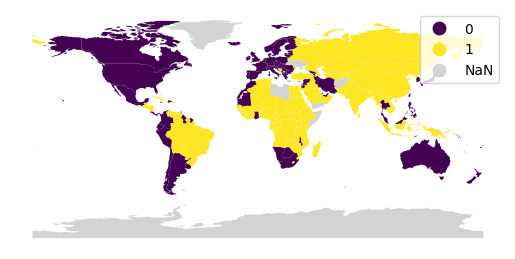

In [ ]:
import geopandas as gpd
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
from difflib import SequenceMatcher
countries['labels'] = None
# Membuat DataFrame untuk negara dan label clusternya
df_sorted.loc[df_sorted["Country"] == "The Philippines", 'Country'] = "Philippines"
df_sorted.loc[df_sorted["Country"] == "Burma", 'Country'] = "Myanmar"
df_sorted.loc[df_sorted["Country"] == "Türkiye", 'Country'] = "Turkiye"
df_sorted.loc[df_sorted["Country"] == "Kyrgyz Republic", 'Country'] = "Kyrgyztan"
df_sorted.loc[df_sorted["Country"] == "Czech Republic", 'Country'] = "Czechia"
df_sorted.loc[df_sorted["Country"] == "Republic of Congo", 'Country'] = "Congo"
df_sorted.loc[df_sorted["Country"] == "Democratic Republic of Congo", 'Country'] = "Dem. Rep. Congo"
df_sorted.loc[df_sorted["Country"] == "The Bahamas ", 'Country'] = "Bahamas"
df_sorted.loc[df_sorted["Country"] == "Equatorial Guinea", 'Country'] = "Republic of Equatorial Guinea"
df_sorted.loc[df_sorted["Country"] == "The Gambia", 'Country'] = "Gambia"

for i, country in enumerate(countries['name']):
    for j, result in enumerate(df_sorted['Country']):
        if ((country[0].lower() == result[0].lower()) and (SequenceMatcher(None, country, result).ratio() >= 0.7)):
            countries['labels'][i] = df_sorted["Cluster"][j]
            break

print(countries.sort_values('name')[['name', 'labels']])

#Legend still needs adjustments
pd.set_option('display.max_rows', None)
countries["name"]
countries.plot(column='labels', missing_kwds={'color': 'lightgrey'}, cmap='viridis', legend = True).set_axis_off()

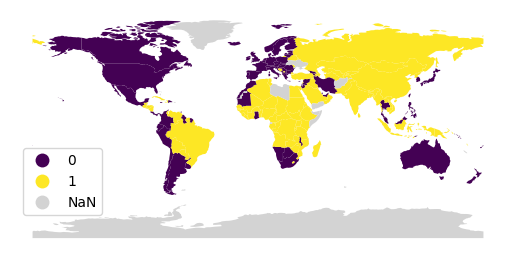

In [ ]:
ax = countries.plot(column='labels',
                    missing_kwds={'color': 'lightgrey'},
                    cmap='viridis',
                    legend=True)

# Remove the axis
ax.set_axis_off()

# Customize the legend
leg = ax.get_legend()
leg.set_bbox_to_anchor((0.05, 0.25, 0.15, 0.2)) # Adjust the position and size of the legend box
leg._legend_box.align = "left" # Align the legend entries to the left

plt.show()

# K-means

In [ ]:
import pandas as pd
df = pd.read_csv(r"freedom_index.csv")

In [ ]:
# K-means Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df_numerical = df.select_dtypes(include=[int, float])
df_numerical = df_numerical.drop(columns = ['Overall Score'] )
df_numerical = df_numerical.drop(columns = ['Year'] )
df_numerical = df_numerical.drop(columns = ['Unnamed: 0'])

pca = PCA(n_components=4)
df_numerical = pca.fit_transform(df_numerical)
kmeans = KMeans(4, random_state=15)
fit = kmeans.fit(df_numerical)
fit_predict = kmeans.fit_predict(df_numerical)
df_numerical = pd.DataFrame(df_numerical)
cluster_map = pd.DataFrame()
cluster_map['data_index'] = df_numerical.index.values
cluster_map['cluster'] = kmeans.labels_
df_kmeans = df
df_kmeans['cluster'] = kmeans.labels_
temp = df_kmeans['cluster']
df_numerical['cluster'] = temp

df_kmeans.sort_values(by='cluster')

df['cluster'].value_counts()
print(df_numerical)


              0          1           2          3  cluster
0    -62.737090 -42.836705  -44.084257   3.665045        2
1    -86.990751 -53.842475   -8.529228  14.762098        2
2    -73.924558 -52.492699  -22.636578  21.934472        2
3    -54.194847 -49.820428  -22.379285  33.584997        2
4    -92.344713 -50.202312   11.443431  -2.183303        2
5   -101.704615 -46.994794   27.352867  -4.040192        2
6    -80.060916 -38.965922    4.122896   4.097946        2
7    -86.890312 -26.499357    5.130660  12.260523        2
8    -90.895051 -45.410485   29.239328  15.002355        2
9    -97.062227 -45.688439   26.253518   0.030917        2
10   -94.466968 -39.123895   15.678054   0.127568        2
11  -107.890956 -22.225264   30.301509  -9.169865        2
12   -93.191591   2.717827  -10.986786   2.235803        2
13   -45.018646 -44.801904   -2.461486  26.392374        2
14   -54.738506 -35.649074    3.335437   4.392571        2
15   -85.107079  12.593241   -1.202541  -3.150207       

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
import pandas as pd

cluster_map = pd.DataFrame()
cluster_map['data_index'] = df_kmeans.index.values
cluster_map['cluster'] = kmeans.labels_
df_kmeans = df
df_kmeans['cluster'] = kmeans.labels_
df_kmeans.sort_values(by='cluster')
df_kmeans.sort_values(by='Country')
df_kmeans['cluster']

0      2
1      2
2      2
3      2
4      2
5      2
6      2
7      2
8      2
9      2
10     2
11     2
12     2
13     2
14     2
15     2
16     2
17     2
18     2
19     2
20     2
21     3
22     2
23     2
24     2
25     2
26     2
27     3
28     2
29     2
30     3
31     2
32     3
33     3
34     2
35     3
36     3
37     2
38     2
39     3
40     2
41     2
42     0
43     2
44     3
45     2
46     3
47     3
48     3
49     2
50     0
51     0
52     3
53     0
54     2
55     0
56     3
57     3
58     3
59     3
60     0
61     2
62     3
63     0
64     3
65     3
66     3
67     3
68     3
69     3
70     3
71     3
72     2
73     2
74     3
75     3
76     3
77     0
78     0
79     2
80     3
81     0
82     3
83     0
84     3
85     3
86     3
87     3
88     3
89     3
90     3
91     0
92     3
93     0
94     3
95     0
96     0
97     3
98     3
99     1
100    0
101    3
102    3
103    1
104    0
105    3
106    3
107    0
108    0
109    1
110    0
1

In [ ]:
sorted_on_country = df_kmeans.sort_values(by='Country')

pd.set_option('display.max_rows', None)
print(sorted_on_country['cluster'])

47     3
163    0
117    1
143    0
46     3
12     2
31     2
69     3
53     0
115    1
40     2
151    1
45     2
71     3
94     3
107    0
164    0
65     3
35     3
123    0
42     0
30     3
132    0
166    0
170    0
55     0
105    3
119    1
15     2
167    1
135    1
20     2
150    0
83     0
130    1
36     3
38     2
174    0
16     2
23     2
90     3
159    1
5      2
103    1
118    2
56     3
113    3
145    0
116    3
158    1
169    1
6      2
106    3
155    1
93     0
11     2
61     2
99     1
32     3
17     2
104    0
112    2
62     3
122    1
165    0
96     0
154    1
88     3
72     2
22     2
125    0
52     3
168    1
2      2
24     2
79     2
33     3
37     2
91     0
66     3
120    0
136    0
74     3
89     3
111    1
141    1
18     2
153    1
133    3
144    1
14     2
4      2
97     3
128    0
44     3
157    0
126    3
49     2
109    1
19     2
67     3
73     2
98     3
75     3
82     3
100    0
139    0
95     0
129    1
10     2
7      2
1

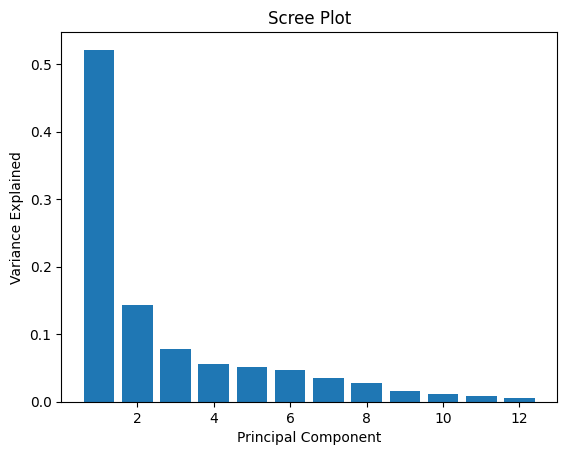

In [ ]:
# Reduksi dimensi menggunakan PCA agar dapat divisualisasikan
#Create Scree Plot to find the num of significant Principle Component
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

df_numerical = df.select_dtypes(include=[int, float])
df_numerical = df_numerical.drop(columns = ['Overall Score'] )
df_numerical = df_numerical.drop(columns = ['Year'] )
df_numerical = df_numerical.drop(columns = ['Unnamed: 0'] )
df_numerical = df_numerical.drop(columns = ['cluster'] )

scaler = StandardScaler()
df_numerical = scaler.fit_transform(df_numerical)

pca = PCA(n_components = df_numerical.shape[1])
X_new = pca.fit_transform(df_numerical)
df_new = pd.DataFrame(X_new)

PC_values = np.arange(pca.n_components_) + 1
plt.bar(PC_values, pca.explained_variance_ratio_)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 2 The average silhouette_score is : 0.28419341061809344
For n_clusters = 3 The average silhouette_score is : 0.23466914281756315
For n_clusters = 4 The average silhouette_score is : 0.21506953548833632
For n_clusters = 5 The average silhouette_score is : 0.20700521861629853
For n_clusters = 6 The average silhouette_score is : 0.17060352980027196


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 7 The average silhouette_score is : 0.15610606773657507
For n_clusters = 8 The average silhouette_score is : 0.1652226052441479


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


For n_clusters = 9 The average silhouette_score is : 0.1523411994496665


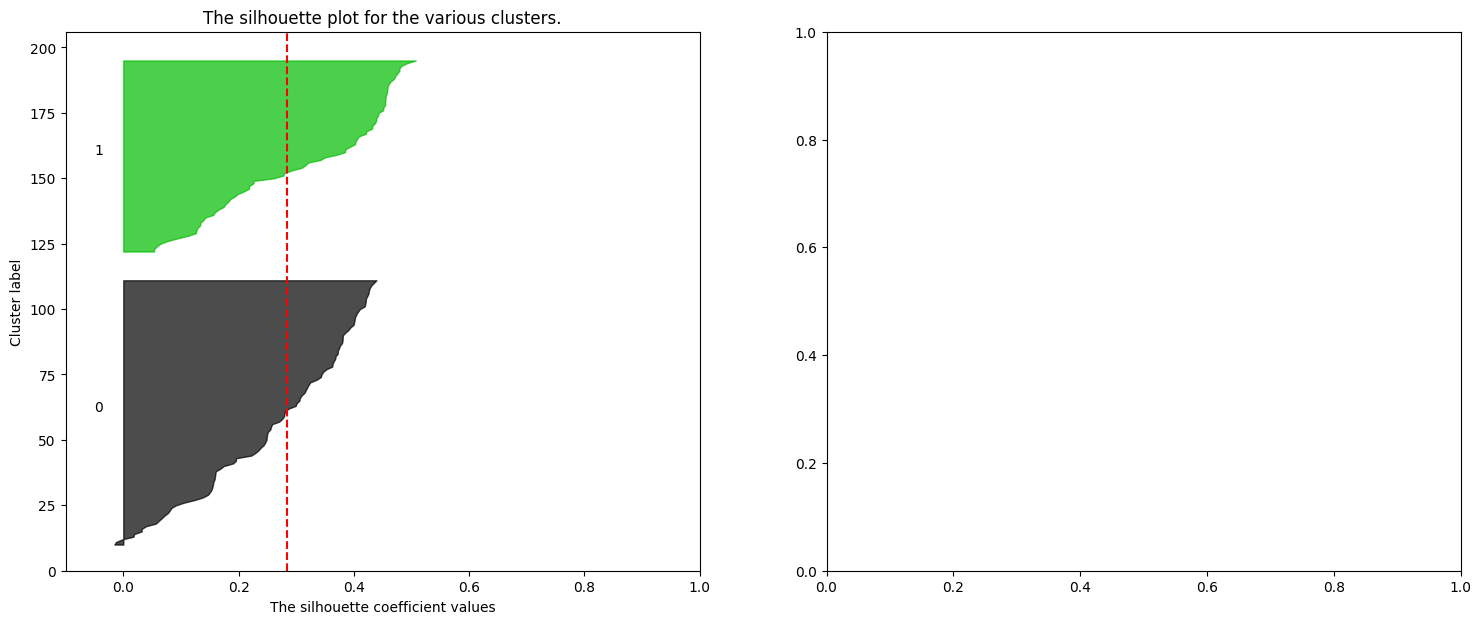

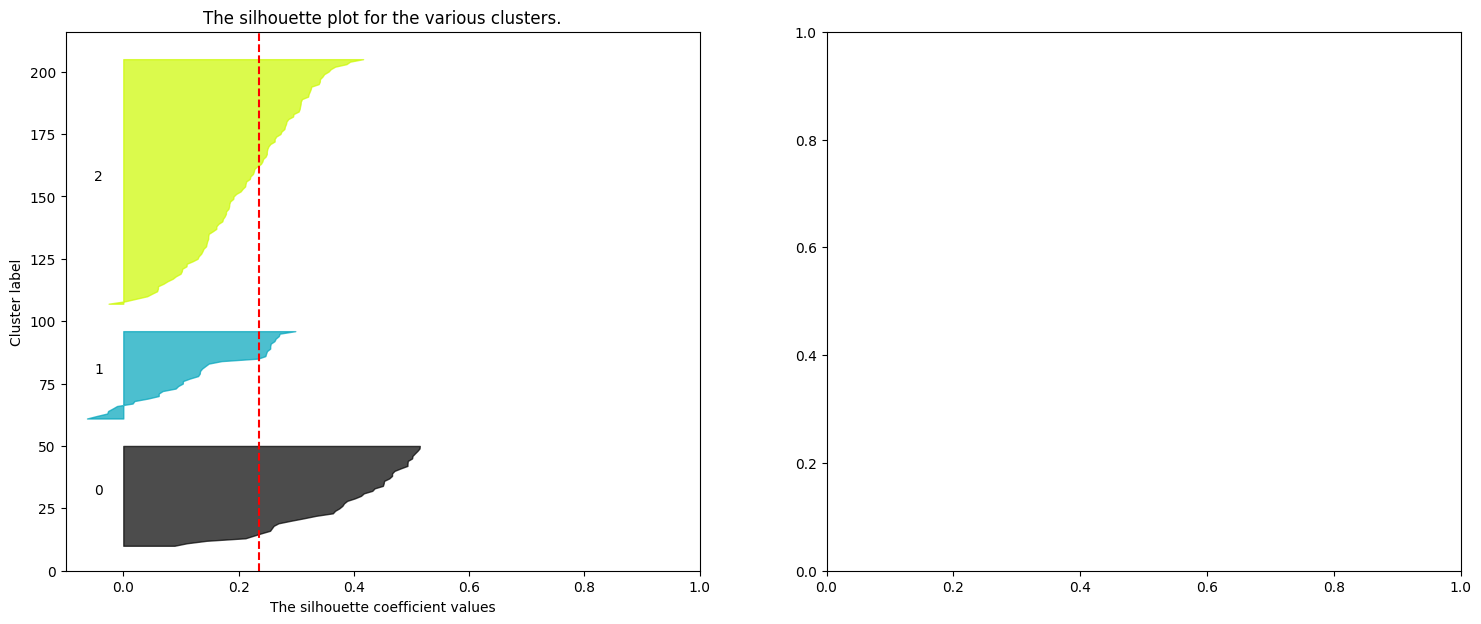

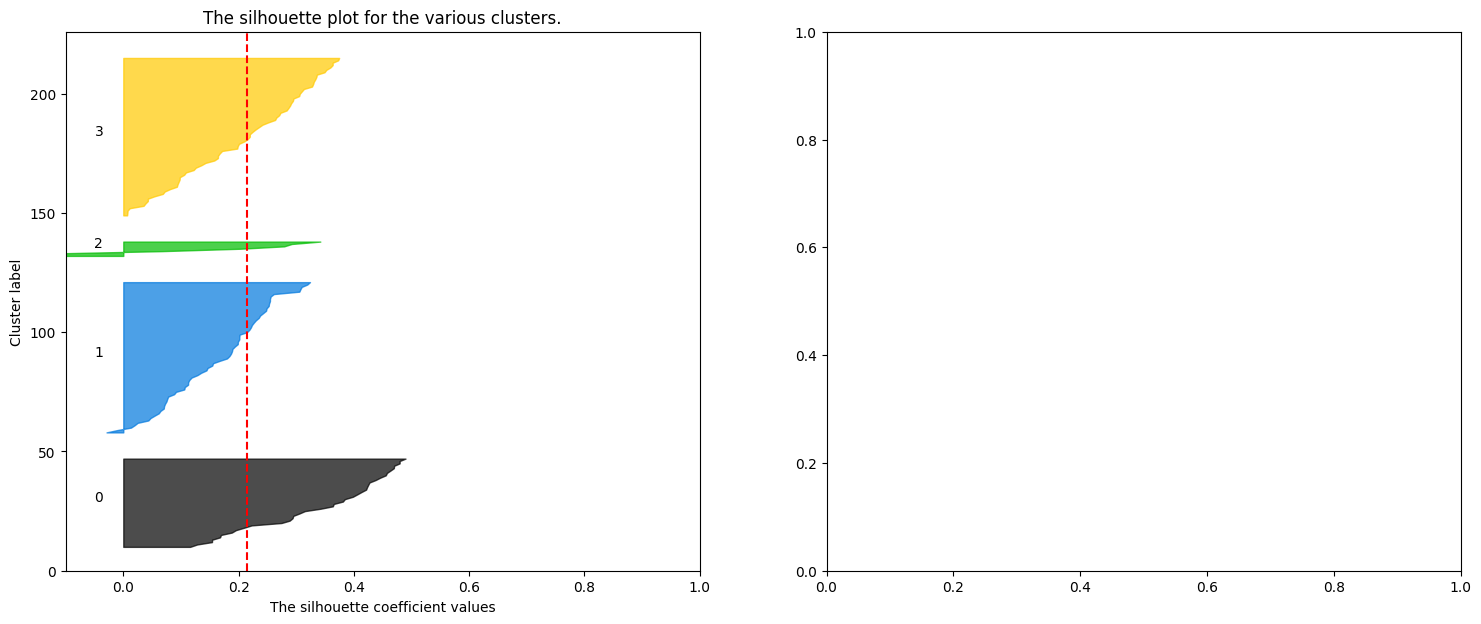

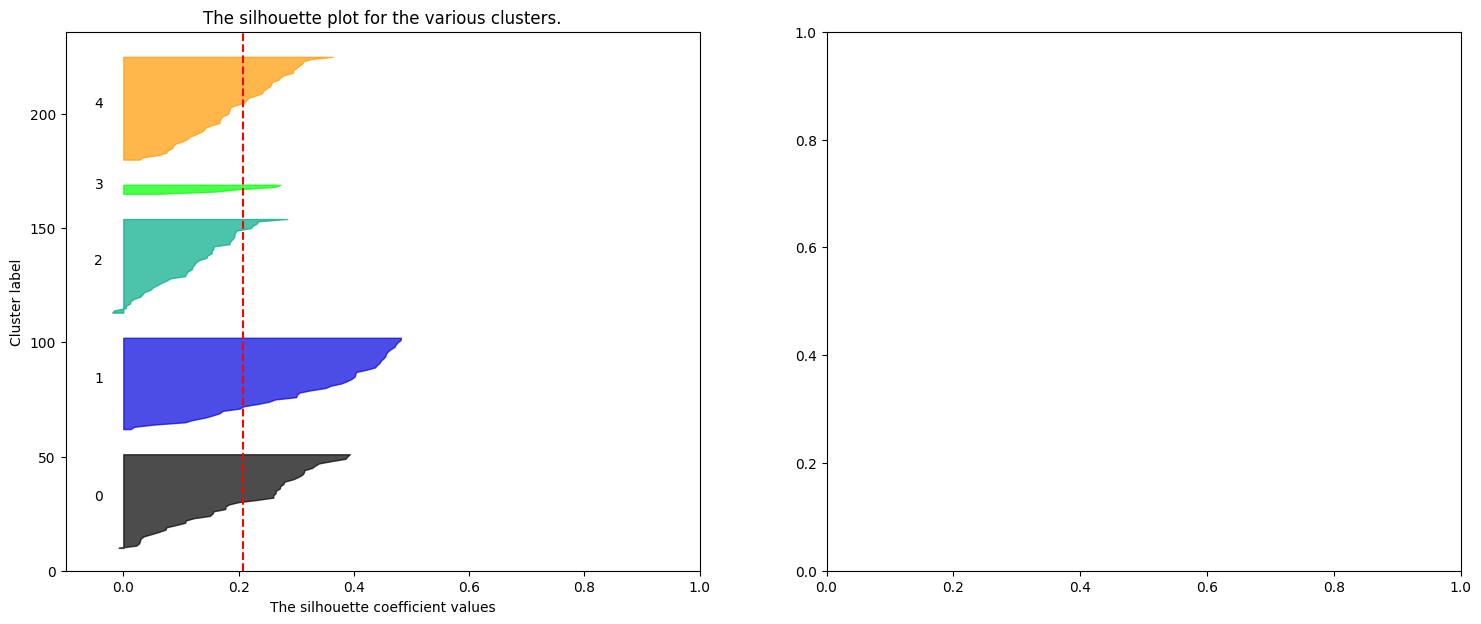

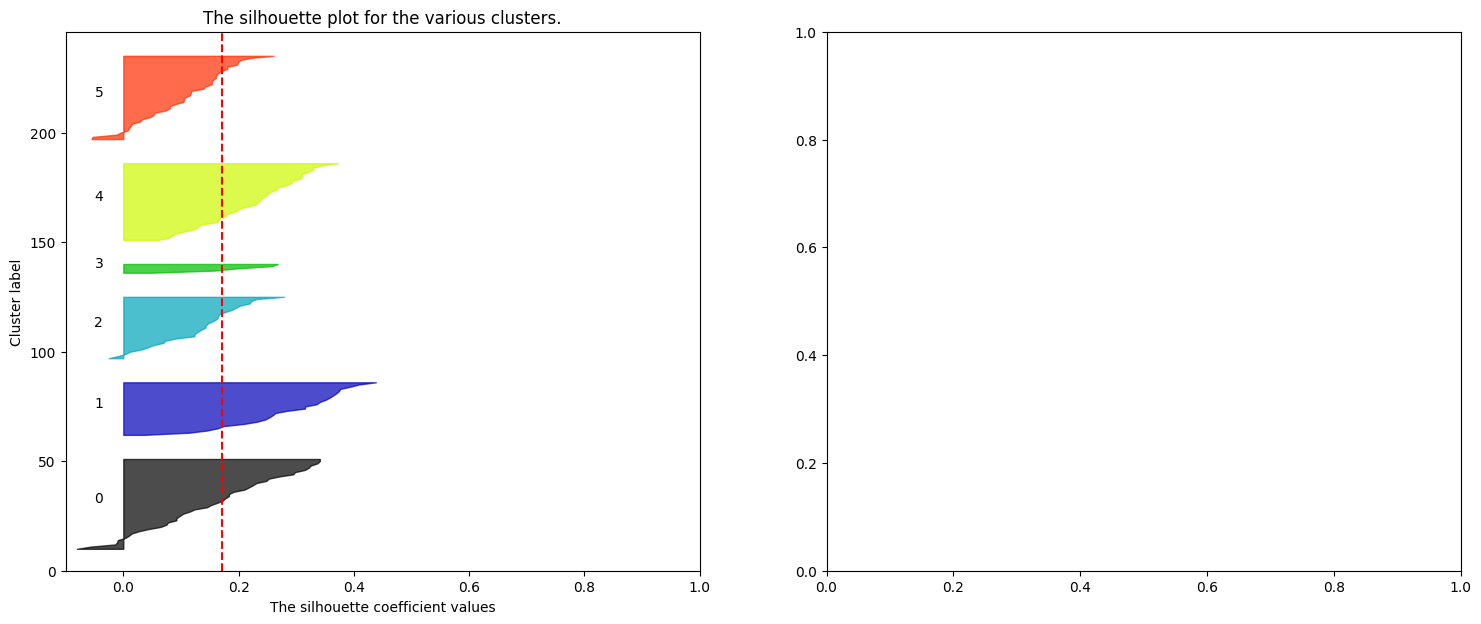

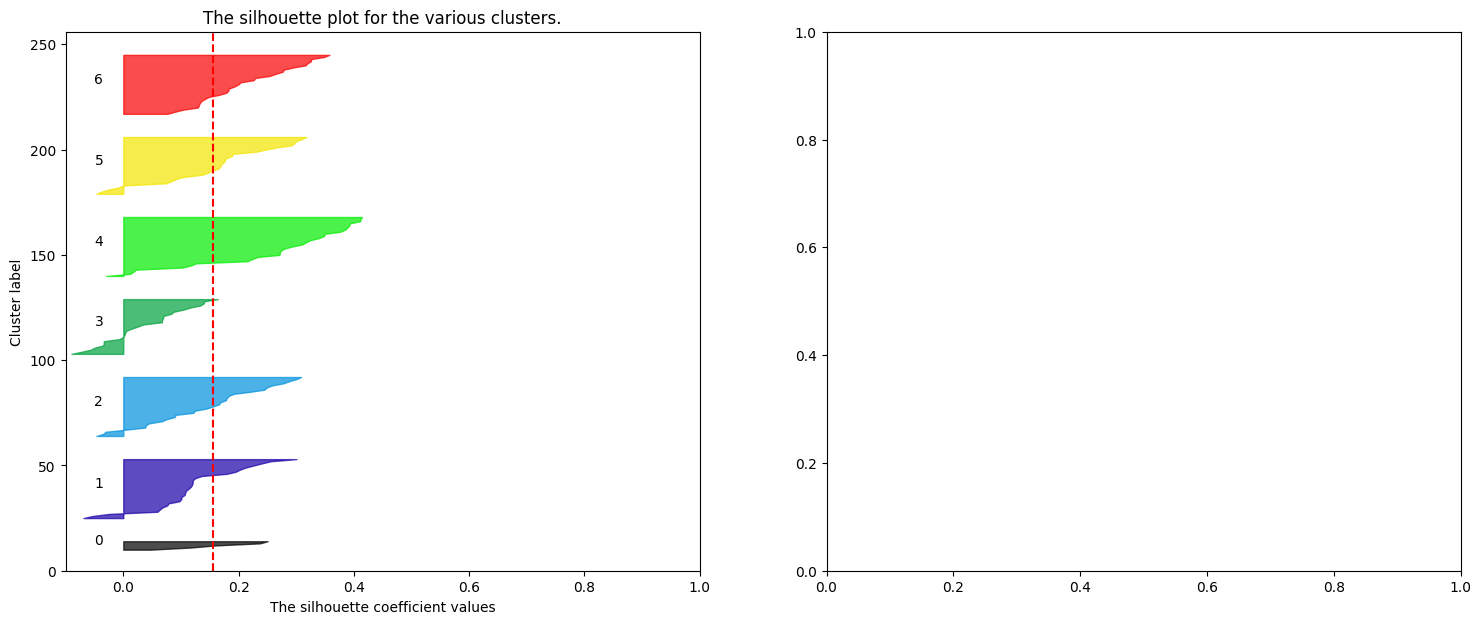

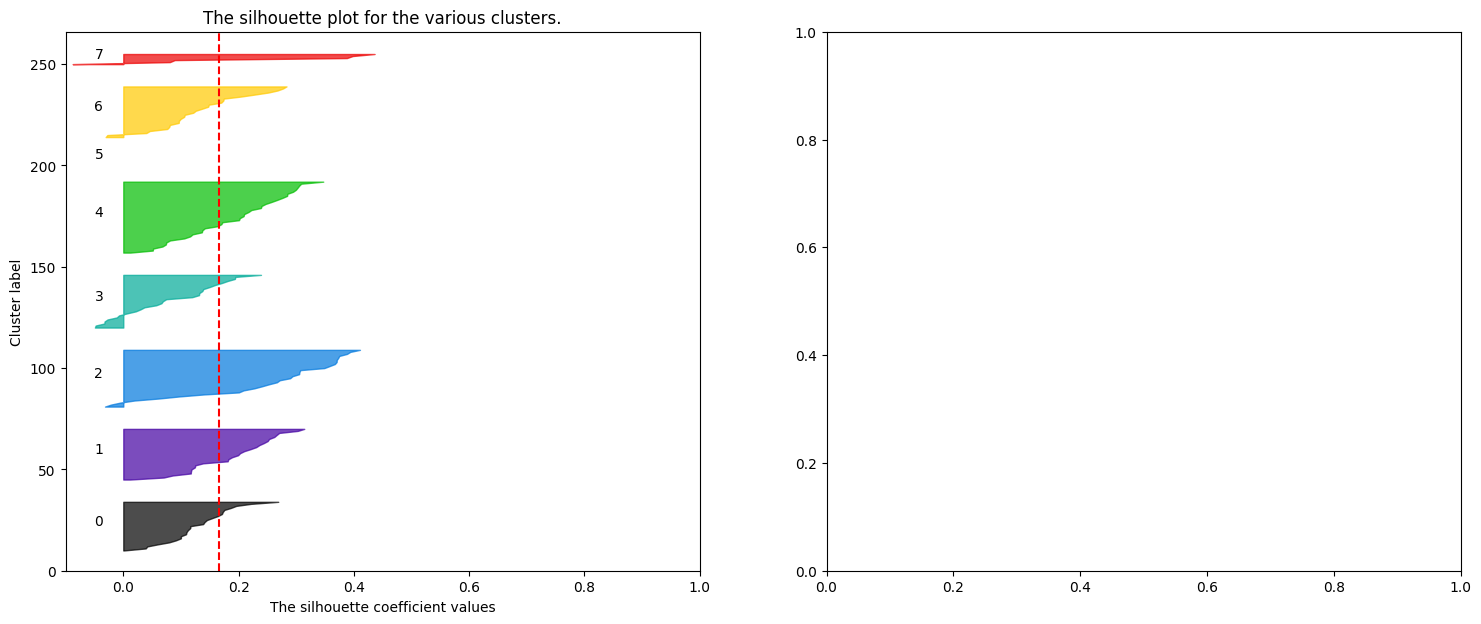

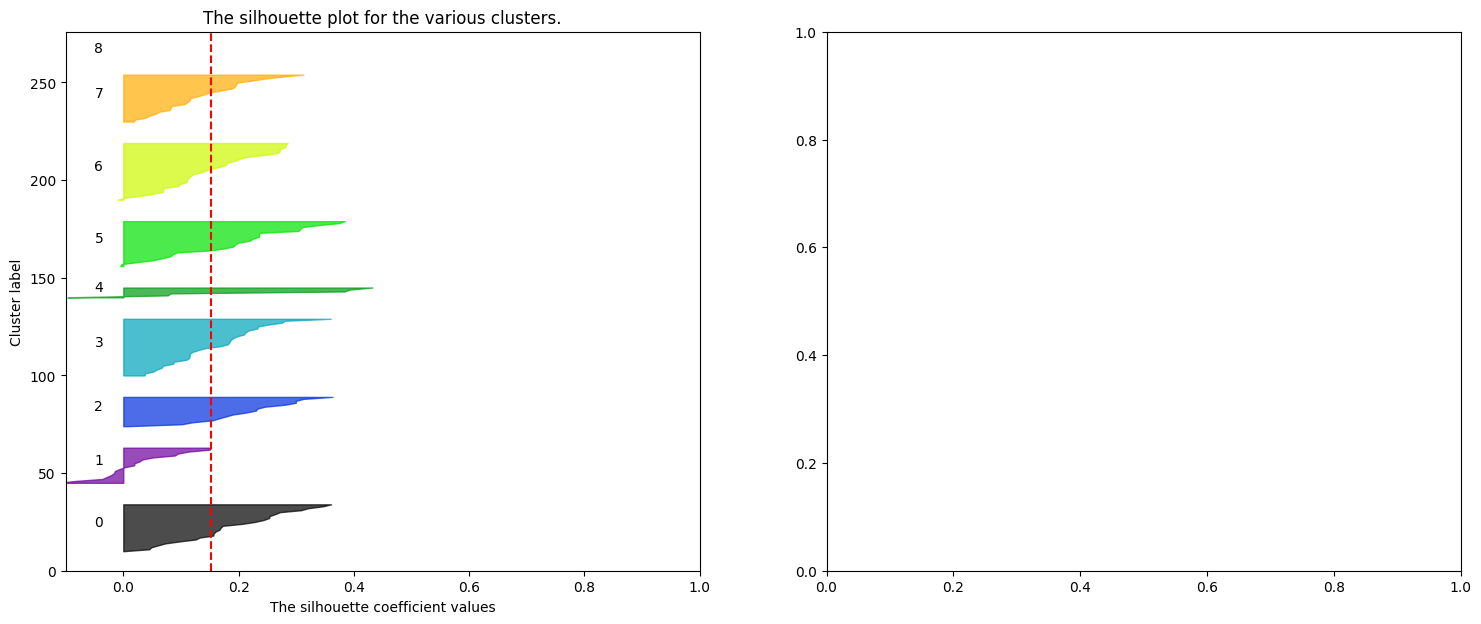

In [ ]:
# K Means
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
X = df_numerical
for n_clusters in range(2, 10):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    clusterer = KMeans(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")


plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

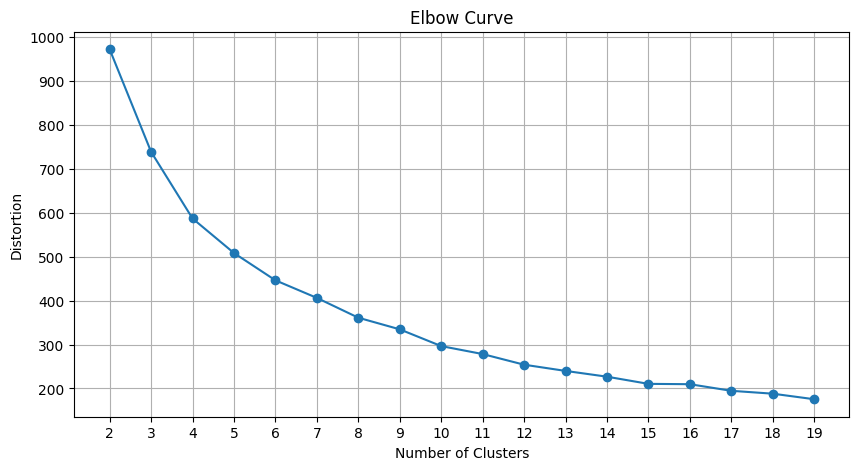

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
pca = PCA(n_components=4)
X = pca.fit_transform(X)
distortions = []
for k in range(2, 20):
    pca = PCA(n_components=4)
    X = pca.fit_transform(X)
    kmeans = KMeans(n_clusters=k, random_state=15)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(range(2, 20), distortions, marker='o')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.xticks(range(2, 20))
plt.grid(True)
plt.show()

In [ ]:
df = df.sort_values(by="Country")
df['cluster']

47     3
163    0
117    1
143    0
46     3
12     2
31     2
69     3
53     0
115    1
40     2
151    1
45     2
71     3
94     3
107    0
164    0
65     3
35     3
123    0
42     0
30     3
132    0
166    0
170    0
55     0
105    3
119    1
15     2
167    1
135    1
20     2
150    0
83     0
130    1
36     3
38     2
174    0
16     2
23     2
90     3
159    1
5      2
103    1
118    2
56     3
113    3
145    0
116    3
158    1
169    1
6      2
106    3
155    1
93     0
11     2
61     2
99     1
32     3
17     2
104    0
112    2
62     3
122    1
165    0
96     0
154    1
88     3
72     2
22     2
125    0
52     3
168    1
2      2
24     2
79     2
33     3
37     2
91     0
66     3
120    0
136    0
74     3
89     3
111    1
141    1
18     2
153    1
133    3
144    1
14     2
4      2
97     3
128    0
44     3
157    0
126    3
49     2
109    1
19     2
67     3
73     2
98     3
75     3
82     3
100    0
139    0
95     0
129    1
10     2
7      2
1

In [ ]:
df = df.sort_values(by="Overall Score", )
df[["Country", "Overall Score", "cluster"]]

,Country,Overall Score,cluster
175,North Korea,2.9,0
174,Cuba,25.7,0
173,Venezuela,28.1,1
172,Sudan,33.9,1
171,Zimbabwe,38.2,1
170,Burundi,38.4,0
169,Eritrea,39.5,1
168,Iran,41.2,1
167,Central African Republic,41.3,1
166,Burma,42.2,0


Geo Map

In [ ]:
import geopandas as gpd
countries = gpd.read_file(
               gpd.datasets.get_path("naturalearth_lowres"))
countries.head()

<ipython-input-109-ada0933c2102>:3: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  gpd.datasets.get_path("naturalearth_lowres"))


,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."


<ipython-input-121-1912b493ff5a>:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


0      2
1      2
2      2
3      2
4      2
5      2
6      2
7      2
8      2
9      2
10     2
11     2
12     2
13     2
14     2
15     2
16     2
17     2
18     2
19     2
20     2
21     3
22     2
23     2
24     2
25     2
26     2
27     3
28     2
29     2
30     3
31     2
32     3
33     3
34     2
35     3
36     3
37     2
38     2
39     3
40     2
41     2
42     0
43     2
44     3
45     2
46     3
47     3
48     3
49     2
50     0
51     0
52     3
53     0
54     2
55     0
56     3
57     3
58     3
59     3
60     0
61     2
62     3
63     0
64     3
65     3
66     3
67     3
68     3
69     3
70     3
71     3
72     2
73     2
74     3
75     3
76     3
77     0
78     0
79     2
80     3
81     0
82     3
83     0
84     3
85     3
86     3
87     3
88     3
89     3
90     3
91     0
92     3
93     0
94     3
95     0
96     0
97     3
98     3
99     1
100    0
101    3
102    3
103    1
104    0
105    3
106    3
107    0
108    0
109    1
110    0
1

<ipython-input-121-1912b493ff5a>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  countries['labels'][i] = df2["cluster"][j]


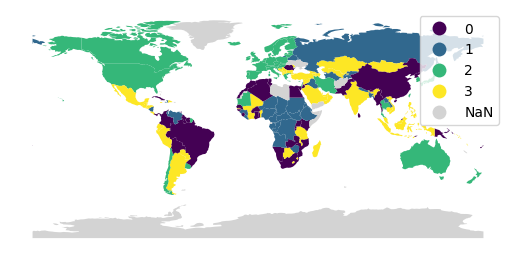

In [ ]:
import geopandas as gpd
countries = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
from difflib import SequenceMatcher
countries['labels'] = None
# Membuat DataFrame untuk negara dan label clusternya
df2 = pd.DataFrame({'Country': country_names, 'cluster': df["cluster"]})
df2.loc[df2["Country"] == "The Philippines", 'Country'] = "Philippines"
df2.loc[df2["Country"] == "Burma", 'Country'] = "Myanmar"
df2.loc[df2["Country"] == "Türkiye", 'Country'] = "Turkiye"
df2.loc[df2["Country"] == "Kyrgyz Republic", 'Country'] = "Kyrgyztan"
df2.loc[df2["Country"] == "Czech Republic", 'Country'] = "Czechia"
df2.loc[df2["Country"] == "Republic of Congo", 'Country'] = "Congo"
df2.loc[df2["Country"] == "Democratic Republic of Congo", 'Country'] = "Dem. Rep. Congo"
df2.loc[df2["Country"] == "The Bahamas ", 'Country'] = "Bahamas"
df2.loc[df2["Country"] == "Equatorial Guinea", 'Country'] = "Republic of Equatorial Guinea"
df2.loc[df2["Country"] == "The Gambia", 'Country'] = "Gambia"

print(df2["cluster"])


for i, country in enumerate(countries['name']):
    for j, result in enumerate(df2['Country']):
        if ((country[0].lower() == result[0].lower()) and (SequenceMatcher(None, country, result).ratio() >= 0.7)):
            countries['labels'][i] = df2["cluster"][j]
            break

print(countries.sort_values('name')[['name', 'labels']])
#Legend still needs adjustments
pd.set_option('display.max_rows', None)
countries["name"]
countries.plot(column='labels', missing_kwds={'color': 'lightgrey'}, cmap='viridis', legend = True).set_axis_off()


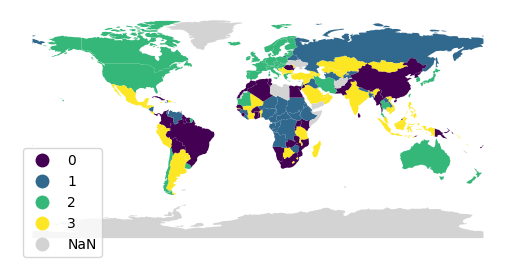

In [ ]:
ax = countries.plot(column='labels',
                    missing_kwds={'color': 'lightgrey'},
                    cmap='viridis',
                    legend=True)

# Remove the axis
ax.set_axis_off()

# Customize the legend
leg = ax.get_legend()
leg.set_bbox_to_anchor((0.05, 0.25, 0.15, 0.2)) # Adjust the position and size of the legend box
leg._legend_box.align = "left" # Align the legend entries to the left

plt.show()